<a href="https://colab.research.google.com/github/Alamgir-JUST/Skill-Morph/blob/main/Ensemble_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Drone IDS with Various Ensemble Approaches**

In [29]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

### **Dataset Importing**

In [30]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Drone IDS Dataset Processed/updated_drone_ids_dataset.csv")

In [32]:
## Original Dataset Link
# https://onlineacademiccommunity.uvic.ca/isot/2024/12/05/drone-datasets/

### **Processed Dataset Link**

In [58]:
## Processed Dataset Link, You may download and work

# https://drive.google.com/file/d/1eX3VsHxkoIoUi_yso_w6LijNVw2H9hax/view?usp=drive_link

In [34]:
df.shape

(301555, 63)

In [35]:
df

,ts,Payload_Length,Var_Payload,Protocol Type,Duration,Entropy,Drone_port,Rate,Srate,Drate,...,Radius,Covariance,Variance,Weight,DS status,Fragments,Sequence number,flow_idle_time,flow_active_time,Label
0,0.009172,-1.348014,-0.966191,-0.328831,0.765486,0.002137,-1.037673,-0.372968,-0.098917,-0.006215,...,-0.873068,-0.983958,0.973405,-0.986035,-0.299227,-0.266974,-0.264555,-0.010915,-0.444785,2
1,0.009173,-1.353516,-0.967686,-0.322009,0.972344,0.004068,-1.037673,-0.391071,-0.109245,-0.006215,...,-0.922930,-0.991757,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.519668,-0.432370,2
2,0.009174,-1.376699,-0.958604,-0.328831,0.765486,-0.046176,-1.037673,-0.361644,-0.109251,-0.006215,...,-0.974530,-0.997553,0.730427,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.423013,2
3,0.009175,-1.414617,-0.953677,-0.322009,0.558629,-0.181737,-1.037673,-0.391160,-0.109241,-0.006077,...,-0.877347,-0.981531,0.730427,0.986792,-0.299227,-0.266974,-0.264555,-0.010915,-0.421956,2
4,0.009175,-1.343496,-0.970667,-0.328831,0.765486,0.002311,-1.037673,-0.380858,-0.109248,-0.006215,...,-0.894850,-0.986919,0.973405,-0.986035,-0.299227,-0.266974,-0.264555,-0.519668,-0.405997,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301550,-0.923558,-1.209701,-0.592404,3.025035,-1.789361,-1.200121,-1.353331,-0.321559,-0.108466,-0.003638,...,-0.113462,-0.553236,0.730427,-1.116040,2.830843,3.684909,3.992016,-0.519668,1.369613,5
301551,-0.924390,-1.608923,-0.989828,3.025035,-1.789361,-1.200121,-1.353331,-0.391285,-0.109078,-0.006215,...,-1.061645,-1.012872,0.973405,1.116797,-0.299227,-0.266974,0.017758,-0.519668,-0.232059,5
301552,-0.924457,-1.454107,-0.851728,3.025035,-1.789361,-1.200121,-1.353331,-0.339860,-0.109087,0.004649,...,-0.966796,-0.991320,0.730427,-1.116040,2.439584,1.050320,-0.198301,-0.519668,2.254120,5
301553,-0.922854,-1.572773,-0.984650,3.025035,-1.789361,-1.200121,-1.353331,-0.362409,-0.108988,0.009998,...,-0.159449,-0.634068,0.973405,1.116797,2.048325,-0.266974,1.404848,-0.519668,1.244857,5


In [36]:
df.columns

Index(['ts', 'Payload_Length', 'Var_Payload', 'Protocol Type', 'Duration',
       'Entropy', 'Drone_port', 'Rate', 'Srate', 'Drate', 'fin_flag_number',
       'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
       'ack_flag_number', 'urg_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count',
       'rst_count', 'max_duration', 'min_duration', 'sum_duration',
       'average_duration', 'std_duration', 'CoAP', 'HTTP', 'HTTPS', 'DNS',
       'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP',
       'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size',
       'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance',
       'Weight', 'DS status', 'Fragments', 'Sequence number', 'flow_idle_time',
       'flow_active_time', 'Label'],
      dtype='object')

In [37]:
df = df.drop(columns=["ts", "Sequence number"], errors="ignore")

print("Updated dataset shape:", df.shape)

Updated dataset shape: (301555, 61)


In [38]:
df['Label'].value_counts()

,count
Label,
0,89648
9,77226
1,71898
5,23122
3,9732
4,8218
6,6099
7,5859
8,5011


## **Types of Label Data**

In [39]:
# Label Encoding Mapping for Drone Intrusion Detection Dataset
# -------------------------------------------------------------
# 0 : Benign Data (Normal drone network traffic)
# 1 : DoS Attacks (Denial-of-Service attack targeting drone communication)
# 2 : Injection (Malicious command or code injection into the system)
# 3 : IP Spoofing (Attacker disguises IP address to impersonate another device)
# 4 : MITM (Man-In-The-Middle attack intercepting communication)
# 5 : Password Cracking (Attempt to break authentication credentials)
# 6 : Payload Manipulation (Modification of transmitted data packets)
# 7 : Replay Attack (Re-sending previously captured packets to disrupt the system)
# 8 : Unauthorized UDP Packets (Sending unauthorized UDP traffic to the drone network)
# 9 : Video Interception Attack (Intercepting or hijacking drone video stream)

## **Drone IDS Dataset: Data Samples per Attack Type**

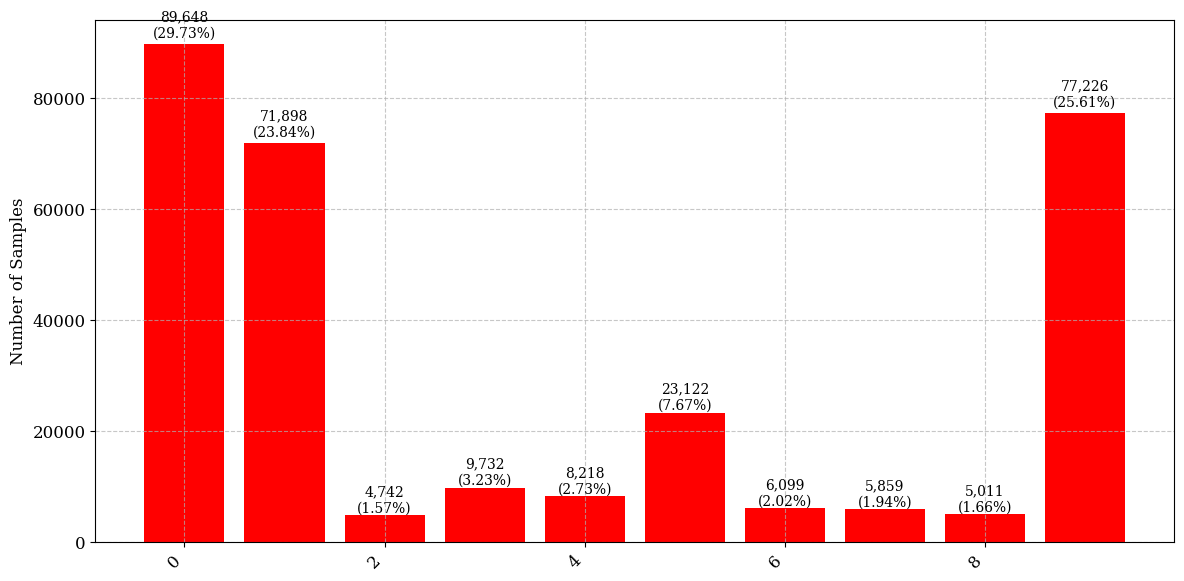

In [40]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(12, 6))
bars = plt.bar(label_counts.index, label_counts.values, color="red")

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.01*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
#plt.title('Drone IDS Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()


# **For Multiclass Classification**

## **Label and Feature Column Divide and Train Test split**

In [41]:
from sklearn.model_selection import train_test_split

# 1. Splitting the preprocessed DataFrame `df`
X = df.drop(columns=['Label'])
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split( #You may apply cross validation
    X, y, test_size=0.2, stratify=y, random_state=42
)

# **Hard voting Classifier Development**
##Each classifier predicts a class, the majority wins.

Training hard-voting ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[Voting] ....................... (1 of 5) Processing LR, total=  48.2s
[Voting] ....................... (2 of 5) Processing DT, total=   6.5s
[Voting] ....................... (3 of 5) Processing RF, total= 1.6min
[Voting] ....................... (4 of 5) Processing ET, total=  34.9s
[Voting] ...................... (5 of 5) Processing HGB, total= 1.0min

Training completed in 4.09 minutes.

HARD-VOTING ENSEMBLE — TEST METRICS
Accuracy                 : 0.999867
Balanced accuracy        : 0.999795
Macro precision          : 0.999278
Macro recall             : 0.999795
Macro F1                 : 0.999536
Weighted precision       : 0.999868
Weighted recall          : 0.999867
Weighted F1              : 0.999867
MCC                      : 0.999830
Cohen kappa              : 0.999830

Training time             : 245.46 seconds
Test prediction time      : 7.061 seconds
Batch-average time/sample : 0.1171 ms
Batch throughput          : 8,540.8 samples/second

PER-CLASS CLASSIFICATION REPORT
   

,Class,Support,Precision,Recall,F1,Specificity,False positive rate,False negative rate
0,Benign,17930,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000
1,DoS,14380,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000
2,Injection,948,0.9958,0.9989,0.9974,0.9999,0.0001,0.0011
3,IP Spoofing,1946,0.9990,1.0000,0.9995,1.0000,0.0000,0.0000
4,MITM,1644,1.0000,0.9994,0.9997,1.0000,0.0000,0.0006
5,Password Cracking,4624,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000
6,Payload Manipulation,1220,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000
7,Replay Attack,1172,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000
8,Unauthorized UDP,1002,0.9980,1.0000,0.9990,1.0000,0.0000,0.0000
9,Video Interception,15445,1.0000,0.9996,0.9998,1.0000,0.0000,0.0004



SECURITY METRICS — BENIGN VS ANY ATTACK
Attack detection rate    : 1.000000
Benign false-alarm rate  : 0.000000
Attack miss rate         : 0.000000
Attack precision         : 1.000000
Binary attack F1         : 1.000000
Benign specificity       : 1.000000

Binary confusion matrix:


,Predicted benign,Predicted attack
Actual benign,17930,0
Actual attack,0,42381



INDIVIDUAL CLASSIFIERS VS ENSEMBLE


,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,MCC,Prediction seconds
Model,,,,,,,,
LR,0.9752,0.8812,0.8792,0.8812,0.8757,0.9749,0.9682,0.0262
DT,0.9999,0.9995,0.9994,0.9995,0.9995,0.9999,0.9998,0.0156
RF,0.9999,0.9999,0.9995,0.9999,0.9997,0.9999,0.9999,0.7991
ET,0.9995,0.9996,0.9973,0.9996,0.9984,0.9995,0.9994,1.0986
HGB,0.9999,0.9997,0.9995,0.9997,0.9996,0.9999,0.9999,2.9772
Hard Voting,0.9999,0.9998,0.9993,0.9998,0.9995,0.9999,0.9998,7.0615



VOTING DIAGNOSTICS
Mean winning-vote fraction: 0.9949
Unanimous predictions:     97.51%
Tied predictions:          2 (0.00%)

FIRST 10 TEST PREDICTIONS


,True label,Predicted label,Correct,Winning vote fraction,Vote tie,LR prediction,DT prediction,RF prediction,ET prediction,HGB prediction
189450,3,3,True,1.0,False,3,3,3,3,3
200436,1,1,True,1.0,False,1,1,1,1,1
171723,9,9,True,1.0,False,9,9,9,9,9
225873,1,1,True,1.0,False,1,1,1,1,1
219967,1,1,True,1.0,False,1,1,1,1,1
102738,9,9,True,1.0,False,9,9,9,9,9
34412,0,0,True,1.0,False,0,0,0,0,0
25299,0,0,True,1.0,False,0,0,0,0,0
149889,9,9,True,1.0,False,9,9,9,9,9
177285,9,9,True,1.0,False,9,9,9,9,9


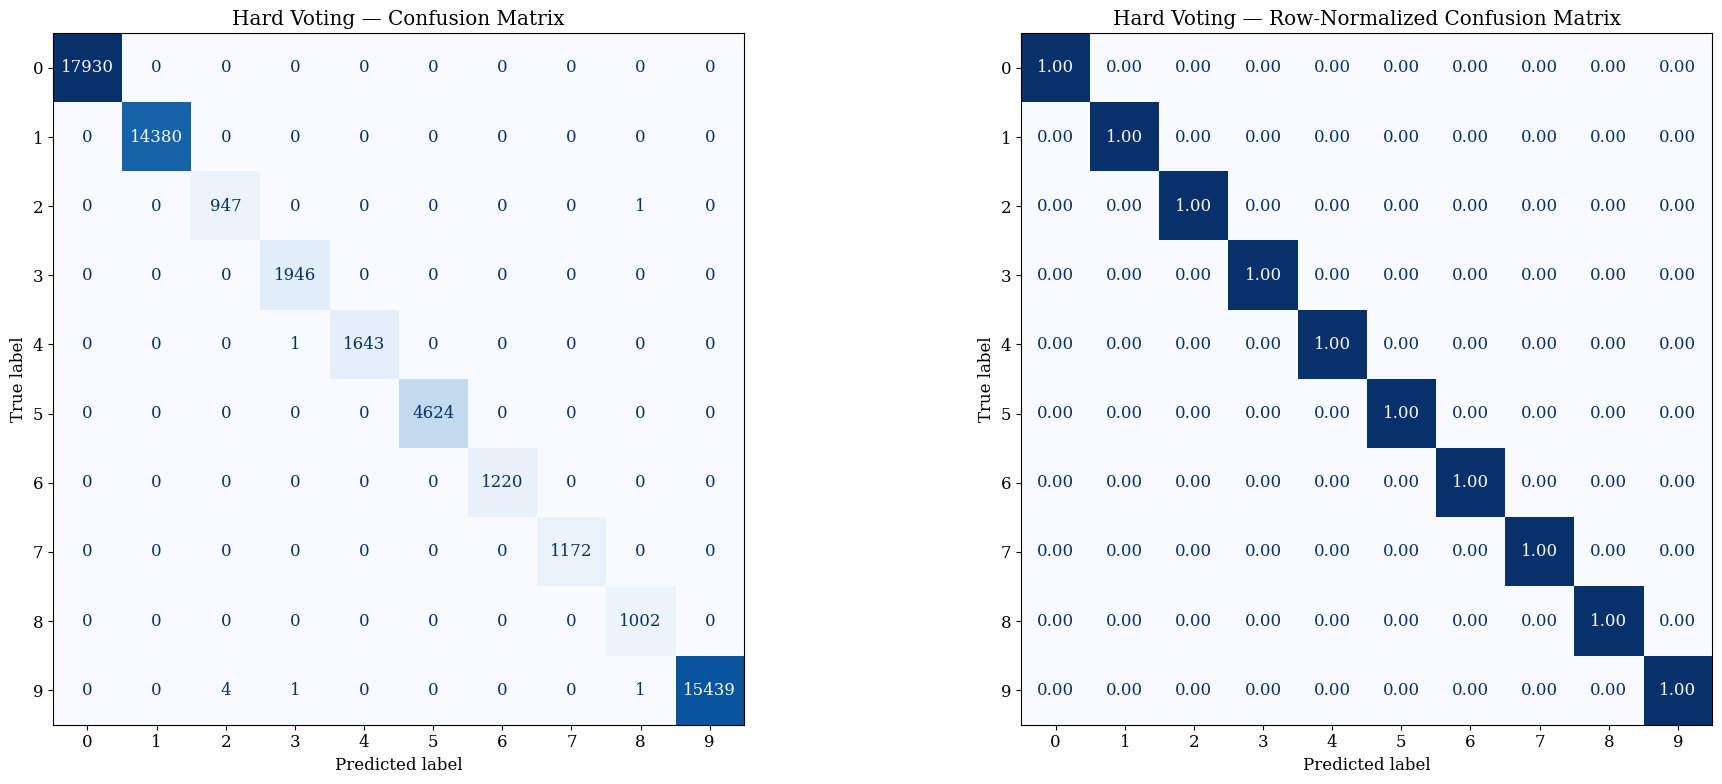

Class mapping:
0: Benign
1: DoS
2: Injection
3: IP Spoofing
4: MITM
5: Password Cracking
6: Payload Manipulation
7: Replay Attack
8: Unauthorized UDP
9: Video Interception


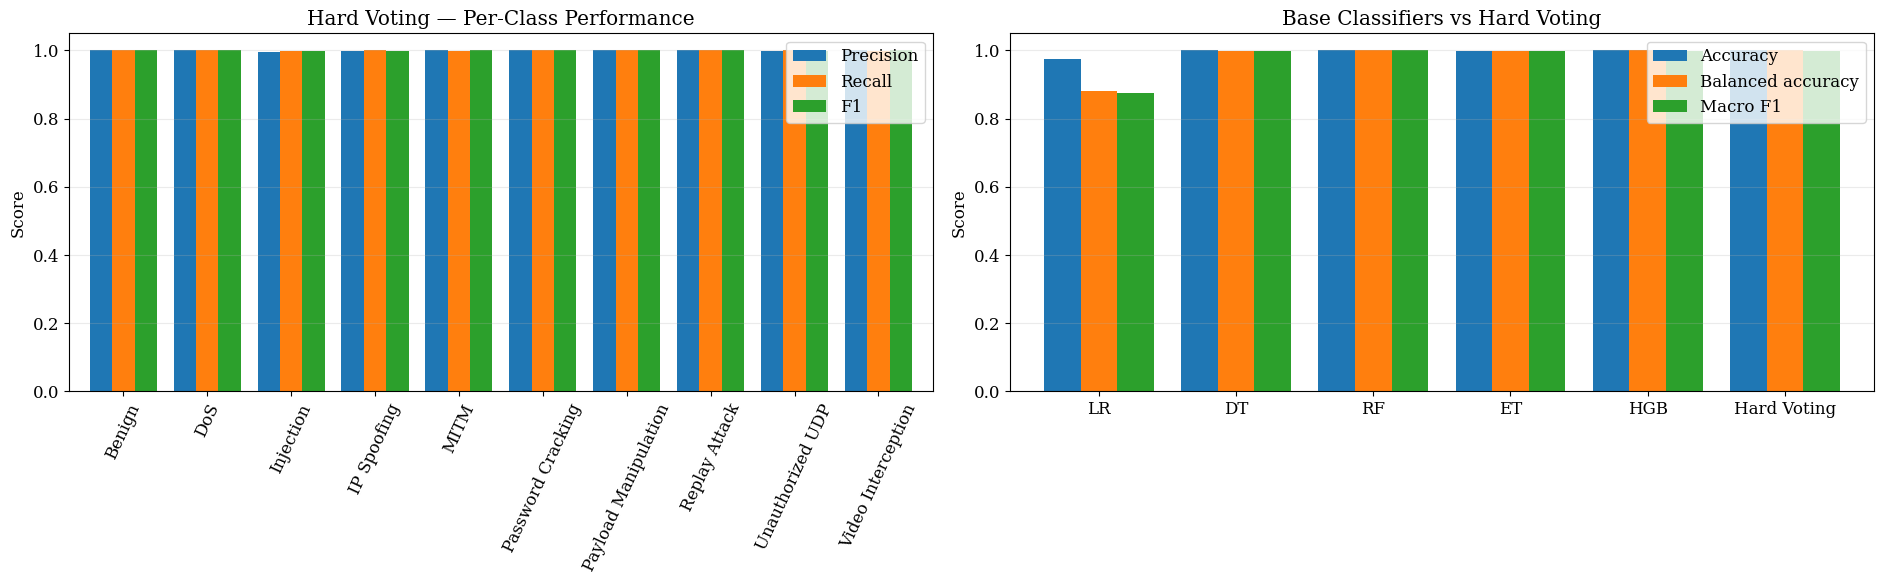


Available outputs:
  hard_voting_model        -> Trained ensemble
  y_pred_hard              -> Test predictions
  comparison_df            -> Model comparison
  classification_report_df -> Classification report
  per_class_metrics        -> Class-wise metrics
  security_metrics         -> Attack-detection metrics
  prediction_details       -> Predictions and voting diagnostics


In [42]:
# ============================================================
# HARD-VOTING ENSEMBLE: TRAINING, PREDICTION AND EVALUATION
# Uses: X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE FIVE BASE CLASSIFIERS, MORE IS ALSO POSSIBLE.
# ------------------------------------------------------------

estimators = [
    (
        "LR",
        LogisticRegression( #Learn about the parameters of all cllassifiers
            max_iter=500,
            solver="lbfgs",
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
    (
        "DT",
        DecisionTreeClassifier(
            max_depth=25,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
    (
        "RF",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "ET",
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "HGB",
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED,
        ),
    ),
]

hard_voting_model = VotingClassifier(
    estimators=estimators,
    voting="hard",
    weights=None,       # One equal vote per classifier
    n_jobs=1,           # Train models sequentially to limit memory use****
    verbose=True,
)

# ------------------------------------------------------------
# 2. TRAIN THE ENSEMBLE
# ------------------------------------------------------------

print("Training hard-voting ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

start = time.perf_counter()
hard_voting_model.fit(X_train, y_train)
training_seconds = time.perf_counter() - start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")

# ------------------------------------------------------------
# 3. PREDICT ON THE TEST SET
# ------------------------------------------------------------

start = time.perf_counter()
y_pred_hard = hard_voting_model.predict(X_test)
prediction_seconds = time.perf_counter() - start

y_true = np.asarray(y_test)
classes = hard_voting_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]

# ------------------------------------------------------------
# 4. OVERALL EVALUATION METRICS
# ------------------------------------------------------------

def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Balanced accuracy": balanced_accuracy_score(actual, predicted),
        "Macro precision": precision_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "Macro recall": recall_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "Weighted precision": precision_score(
            actual, predicted, average="weighted", zero_division=0
        ),
        "Weighted recall": recall_score(
            actual, predicted, average="weighted", zero_division=0
        ),
        "Weighted F1": f1_score(
            actual, predicted, average="weighted", zero_division=0
        ),
        "MCC": matthews_corrcoef(actual, predicted),
        "Cohen kappa": cohen_kappa_score(actual, predicted),
    }


hard_metrics = calculate_metrics(y_true, y_pred_hard)

print("\n" + "=" * 65)
print("HARD-VOTING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in hard_metrics.items():
    print(f"{metric:<25}: {value:.6f}")

print(f"\nTraining time             : {training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

# Batch-average timing is not single-packet deployment latency.

# ------------------------------------------------------------
# 5. PER-CLASS CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 65)

print(classification_report(
    y_true,
    y_pred_hard,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

classification_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred_hard,
        labels=classes,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T

# ------------------------------------------------------------
# 6. CLASS-WISE SPECIFICITY AND ERROR RATES
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred_hard, labels=classes)

tp = np.diag(cm)
fn = cm.sum(axis=1) - tp
fp = cm.sum(axis=0) - tp
tn = cm.sum() - tp - fn - fp


def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan),
        where=denominator != 0,
    )


per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Support": cm.sum(axis=1),
    "Precision": safe_divide(tp, tp + fp),
    "Recall": safe_divide(tp, tp + fn),
    "F1": safe_divide(2 * tp, 2 * tp + fp + fn),
    "Specificity": safe_divide(tn, tn + fp),
    "False positive rate": safe_divide(fp, fp + tn),
    "False negative rate": safe_divide(fn, fn + tp),
})

print("\nCLASS-WISE ONE-VS-REST METRICS")
display(per_class_metrics.round(4))

# ------------------------------------------------------------
# 7. SECURITY METRICS: BENIGN VS ANY ATTACK
# ------------------------------------------------------------

actual_attack = (y_true != 0).astype(int)
predicted_attack = (y_pred_hard != 0).astype(int)

binary_cm = confusion_matrix(
    actual_attack, predicted_attack, labels=[0, 1]
)

tn_b, fp_b, fn_b, tp_b = binary_cm.ravel()


def ratio(numerator, denominator):
    return numerator / denominator if denominator else np.nan


security_metrics = {
    "Attack detection rate": ratio(tp_b, tp_b + fn_b),
    "Benign false-alarm rate": ratio(fp_b, fp_b + tn_b),
    "Attack miss rate": ratio(fn_b, fn_b + tp_b),
    "Attack precision": ratio(tp_b, tp_b + fp_b),
    "Binary attack F1": f1_score(
        actual_attack, predicted_attack, zero_division=0
    ),
    "Benign specificity": ratio(tn_b, tn_b + fp_b),
}

print("\n" + "=" * 65)
print("SECURITY METRICS — BENIGN VS ANY ATTACK")
print("=" * 65)

for metric, value in security_metrics.items():
    print(f"{metric:<25}: {value:.6f}")

print("\nBinary confusion matrix:")
display(pd.DataFrame(
    binary_cm,
    index=["Actual benign", "Actual attack"],
    columns=["Predicted benign", "Predicted attack"],
))

# Wrong attack-type predictions still count as attack detection
# in this binary assessment.

# ------------------------------------------------------------
# 8. COMPARE ALREADY-TRAINED BASE MODELS — NO RETRAINING
# ------------------------------------------------------------

comparison_rows = []
base_predictions = {}

for name, fitted_model in hard_voting_model.named_estimators_.items():
    start = time.perf_counter()

    # VotingClassifier internally encodes target labels.
    encoded_predictions = fitted_model.predict(X_test)
    predictions = hard_voting_model.le_.inverse_transform(
        np.asarray(encoded_predictions, dtype=int)
    )

    elapsed = time.perf_counter() - start
    base_predictions[name] = predictions

    comparison_rows.append({
        "Model": name,
        **calculate_metrics(y_true, predictions),
        "Prediction seconds": elapsed,
    })

comparison_rows.append({
    "Model": "Hard Voting",
    **hard_metrics,
    "Prediction seconds": prediction_seconds,
})

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")

print("\nINDIVIDUAL CLASSIFIERS VS ENSEMBLE")
display(comparison_df[
    [
        "Accuracy",
        "Balanced accuracy",
        "Macro precision",
        "Macro recall",
        "Macro F1",
        "Weighted F1",
        "MCC",
        "Prediction seconds",
    ]
].round(4))

# ------------------------------------------------------------
# 9. VOTING AGREEMENT AND TIES
# ------------------------------------------------------------

vote_matrix = np.column_stack(list(base_predictions.values()))

vote_counts = np.column_stack([
    (vote_matrix == c).sum(axis=1) for c in classes
])

highest_votes = vote_counts.max(axis=1)
agreement = highest_votes / vote_matrix.shape[1]
ties = (vote_counts == highest_votes[:, None]).sum(axis=1) > 1

print("\nVOTING DIAGNOSTICS")
print(f"Mean winning-vote fraction: {agreement.mean():.4f}")
print(f"Unanimous predictions:     {(agreement == 1).mean():.2%}")
print(f"Tied predictions:          {ties.sum():,} ({ties.mean():.2%})")

# Five classifiers can still tie in multiclass classification:
# e.g., 2 votes / 2 votes / 1 vote.
# sklearn resolves equal-weight ties using the lowest encoded
# class among tied classes. Vote fraction is NOT a probability.

prediction_details = pd.DataFrame(
    {
        "True label": y_true,
        "Predicted label": y_pred_hard,
        "Correct": y_true == y_pred_hard,
        "Winning vote fraction": agreement,
        "Vote tie": ties,
        **{
            f"{name} prediction": pred
            for name, pred in base_predictions.items()
        },
    },
    index=getattr(X_test, "index", None),
)

print("\nFIRST 10 TEST PREDICTIONS")
display(prediction_details.head(10))

# ------------------------------------------------------------
# 10. CONFUSION MATRICES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes,
).plot(
    ax=axes[0],
    cmap="Blues",
    values_format="d",
    colorbar=False,
)
axes[0].set_title("Hard Voting — Confusion Matrix")

normalized_cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=classes,
).plot(
    ax=axes[1],
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
)
axes[1].set_title("Hard Voting — Row-Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

print("Class mapping:")
for c, name in zip(classes, class_names):
    print(f"{c}: {name}")

# ------------------------------------------------------------
# 11. PERFORMANCE CHARTS
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(19, 6))

per_class_metrics.set_index("Class")[
    ["Precision", "Recall", "F1"]
].plot.bar(ax=axes[0], width=0.8)

axes[0].set_title("Hard Voting — Per-Class Performance")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=65)
axes[0].grid(axis="y", alpha=0.25)

comparison_df[
    ["Accuracy", "Balanced accuracy", "Macro F1"]
].plot.bar(ax=axes[1], width=0.8)

axes[1].set_title("Base Classifiers vs Hard Voting")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("\nAvailable outputs:")
print("  hard_voting_model        -> Trained ensemble")
print("  y_pred_hard              -> Test predictions")
print("  comparison_df            -> Model comparison")
print("  classification_report_df -> Classification report")
print("  per_class_metrics        -> Class-wise metrics")
print("  security_metrics         -> Attack-detection metrics")
print("  prediction_details       -> Predictions and voting diagnostics")

# **Soft voting Classifier Development**
## Average the predicted class probabilities.

Training soft-voting ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[Voting] ....................... (1 of 5) Processing LR, total=  32.4s
[Voting] ....................... (2 of 5) Processing DT, total=   6.3s
[Voting] ....................... (3 of 5) Processing RF, total= 1.6min
[Voting] ....................... (4 of 5) Processing ET, total=  33.8s
[Voting] ...................... (5 of 5) Processing HGB, total= 1.0min

Training completed in 3.84 minutes.

SOFT-VOTING ENSEMBLE — TEST METRICS
Accuracy                      : 0.999901
Balanced accuracy             : 0.999808
Macro precision               : 0.999487
Macro recall                  : 0.999808
Macro F1                      : 0.999647
Weighted precision            : 0.999901
Weighted recall               : 0.999901
Weighted F1                   : 0.999901
MCC                           : 0.999872
Cohen kappa                   : 0.999872
Log loss                      : 0.013777
Multiclass Brier score        : 0.002635
Macro ROC-AUC (OvR)           : 0.999999
Weighted ROC-AUC (OvR)        : 1.0000

,Class,Support,Precision,Recall,F1,Specificity,False positive rate,False negative rate,ROC-AUC (OvR),Average precision
0,Benign,17930,1.0000,1.0000,1.0000,1.0,0.0,0.0000,1.0,1.0000
1,DoS,14380,1.0000,1.0000,1.0000,1.0,0.0,0.0000,1.0,1.0000
2,Injection,948,0.9979,0.9989,0.9984,1.0,0.0,0.0011,1.0,0.9999
3,IP Spoofing,1946,0.9990,1.0000,0.9995,1.0,0.0,0.0000,1.0,1.0000
4,MITM,1644,1.0000,0.9994,0.9997,1.0,0.0,0.0006,1.0,0.9998
5,Password Cracking,4624,1.0000,1.0000,1.0000,1.0,0.0,0.0000,1.0,1.0000
6,Payload Manipulation,1220,1.0000,1.0000,1.0000,1.0,0.0,0.0000,1.0,1.0000
7,Replay Attack,1172,1.0000,1.0000,1.0000,1.0,0.0,0.0000,1.0,1.0000
8,Unauthorized UDP,1002,0.9980,1.0000,0.9990,1.0,0.0,0.0000,1.0,1.0000
9,Video Interception,15445,1.0000,0.9997,0.9999,1.0,0.0,0.0003,1.0,1.0000



SECURITY METRICS — BENIGN VS ANY ATTACK
Attack detection rate         : 1.000000
Benign false-alarm rate       : 0.000000
Attack miss rate              : 0.000000
Attack precision              : 1.000000
Binary attack F1              : 1.000000
Benign specificity            : 1.000000
Attack ROC-AUC                : 1.000000
Attack average precision      : 1.000000


...

,Accuracy,Balanced accuracy,Macro F1,Weighted F1,MCC,Macro ROC-AUC (OvR),Macro average precision,Log loss,Multiclass Brier score,Prediction seconds
Model,,,,,,,,,,
LR,0.9752,0.8812,0.8757,0.9749,0.9682,0.9979,0.8968,0.1000,0.0372,0.0484
DT,0.9999,0.9995,0.9995,0.9999,0.9998,0.9998,0.9992,0.0043,0.0003,0.0159
RF,0.9999,0.9999,0.9997,0.9999,0.9999,1.0000,1.0000,0.0014,0.0003,0.8242
ET,0.9995,0.9996,0.9984,0.9995,0.9994,1.0000,0.9999,0.0179,0.0040,1.1248
HGB,0.9999,0.9997,0.9996,0.9999,0.9999,1.0000,1.0000,0.0002,0.0001,3.0000
Soft Voting,0.9999,0.9998,0.9996,0.9999,0.9999,1.0000,1.0000,0.0138,0.0026,6.7764



FIRST 10 TEST PREDICTIONS


,True label,Predicted label,Correct,Max predicted probability,Top-two probability margin,Attack probability
189450,3,3,True,0.982475,0.969673,0.999993
200436,1,1,True,0.998161,0.997304,0.999997
171723,9,9,True,0.994808,0.989743,0.994935
225873,1,1,True,0.997819,0.996757,0.999986
219967,1,1,True,0.998200,0.997593,0.999730
102738,9,9,True,0.999551,0.999230,0.999679
34412,0,0,True,0.999896,0.999794,0.000104
25299,0,0,True,0.996860,0.993720,0.003140
149889,9,9,True,0.998552,0.997105,0.998553
177285,9,9,True,0.999598,0.999323,0.999725



FIRST 5 CLASS-PROBABILITY VECTORS


,P(Benign),P(DoS),P(Injection),P(IP Spoofing),P(MITM),P(Password Cracking),P(Payload Manipulation),P(Replay Attack),P(Unauthorized UDP),P(Video Interception)
189450,0.0000,0.0003,0.0002,0.9825,0.0002,0.0,0.0128,0.0039,0.0002,0.0000
200436,0.0000,0.9982,0.0009,0.0002,0.0002,0.0,0.0002,0.0002,0.0004,0.0000
171723,0.0051,0.0001,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.9948
225873,0.0000,0.9978,0.0005,0.0011,0.0002,0.0,0.0002,0.0002,0.0002,0.0000
219967,0.0003,0.9982,0.0002,0.0002,0.0002,0.0,0.0002,0.0002,0.0002,0.0006


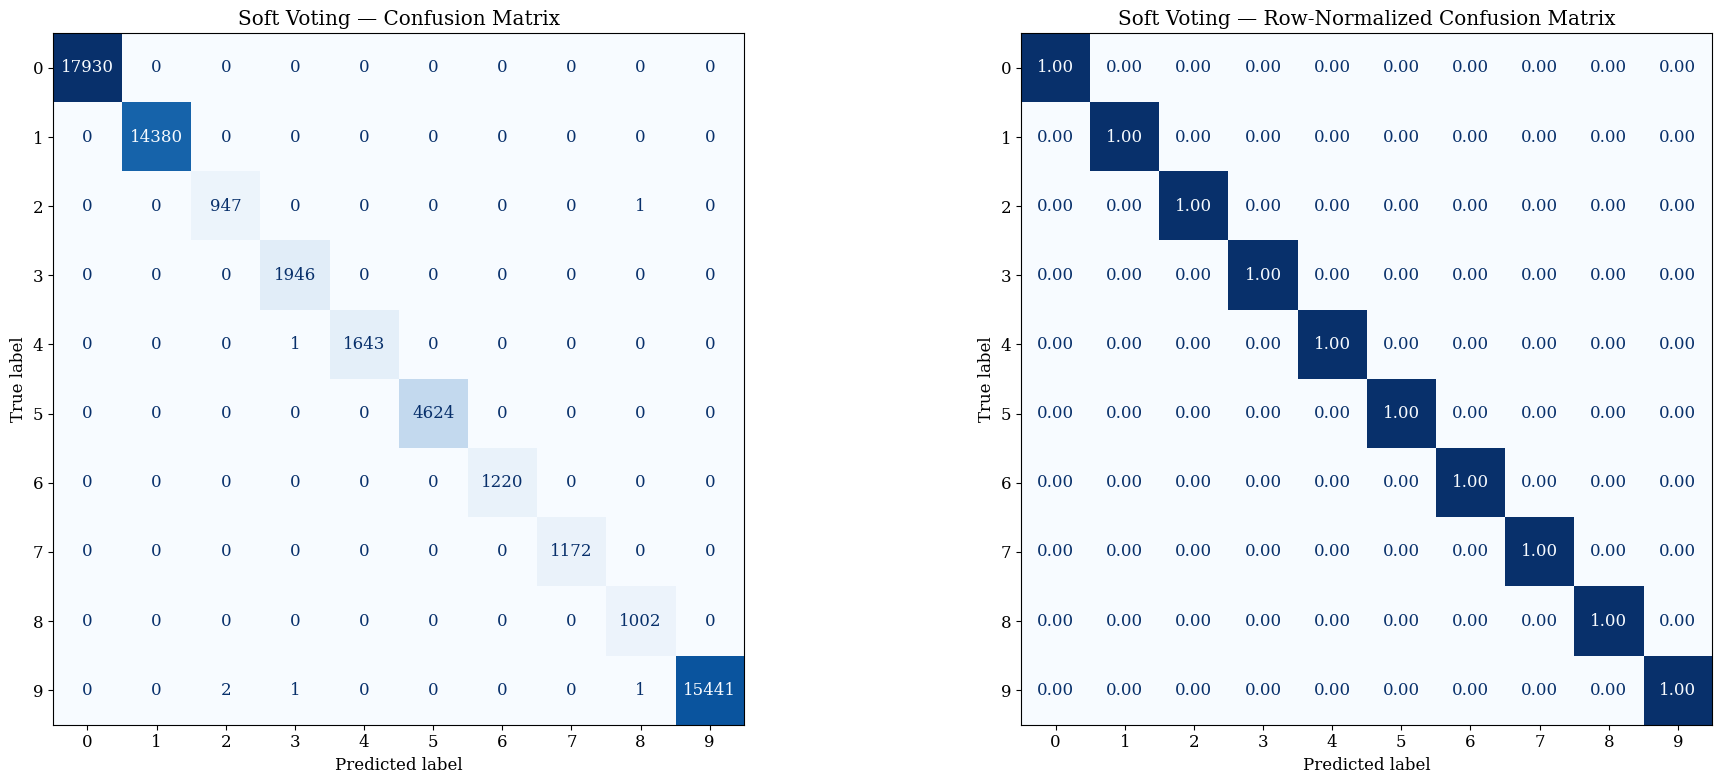

Class mapping:
0: Benign
1: DoS
2: Injection
3: IP Spoofing
4: MITM
5: Password Cracking
6: Payload Manipulation
7: Replay Attack
8: Unauthorized UDP
9: Video Interception


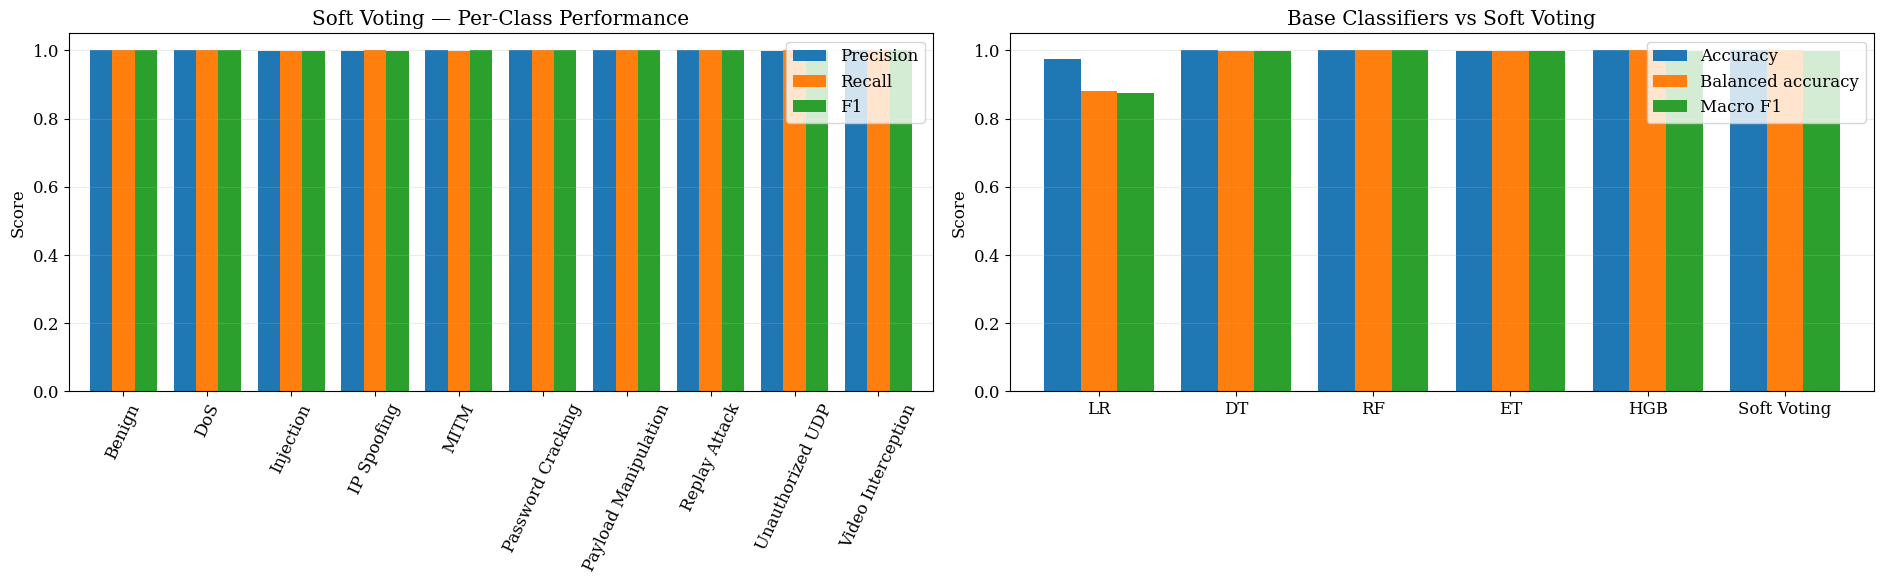

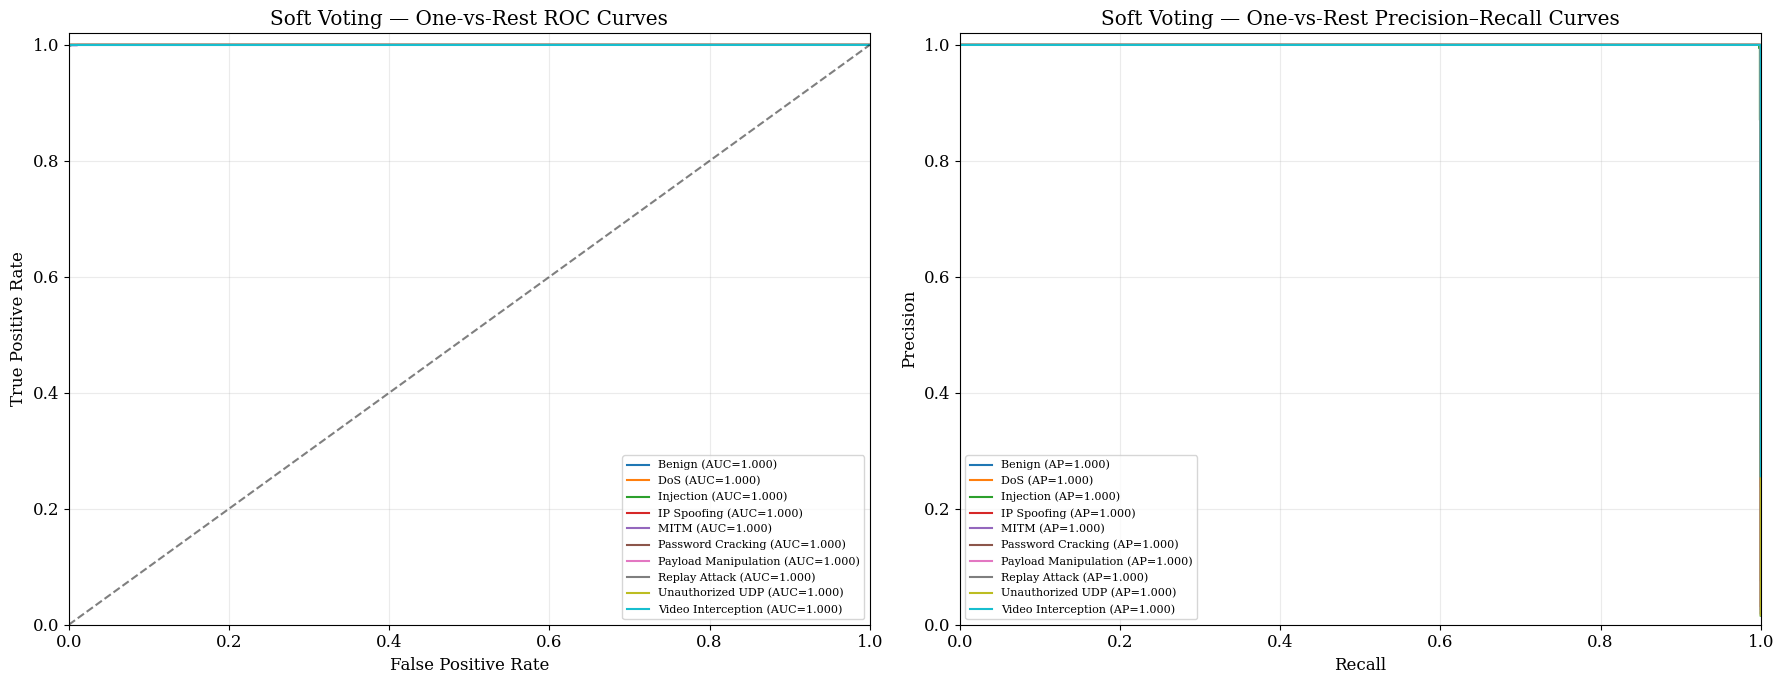


Available outputs:
  soft_voting_model             -> Trained ensemble
  y_pred_soft                   -> Test predictions
  y_proba_soft                  -> Class probabilities
  soft_metrics                  -> Overall metrics
  soft_comparison_df            -> Model comparison
  soft_classification_report_df -> Classification report
  soft_per_class_metrics        -> Class-wise metrics
  soft_security_metrics         -> Attack-detection metrics
  soft_prediction_details       -> Predictions and margins
  soft_probability_df           -> Named probability columns


In [43]:
# ============================================================
# SOFT-VOTING ENSEMBLE: TRAINING, PREDICTION AND EVALUATION
# Uses: X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    log_loss,
    roc_curve,
    precision_recall_curve,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE BASE CLASSIFIERS
# ------------------------------------------------------------

estimators = [
    (
        "LR",
        LogisticRegression(
            max_iter=100,
            solver="lbfgs",
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
    (
        "DT",
        DecisionTreeClassifier(
            max_depth=25,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
    (
        "RF",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "ET",
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "HGB",
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED,
        ),
    ),
]

soft_voting_model = VotingClassifier(
    estimators=estimators,
    voting="soft",
    weights=None,       # Equal probability weight for all models
    n_jobs=1,           # Limit concurrent training memory usage
    verbose=True,
)

# ------------------------------------------------------------
# 2. TRAIN THE ENSEMBLE
# ------------------------------------------------------------

print("Training soft-voting ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

start = time.perf_counter()
soft_voting_model.fit(X_train, y_train)
training_seconds = time.perf_counter() - start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")

# ------------------------------------------------------------
# 3. PREDICT PROBABILITIES AND CLASS LABELS
# Probability columns follow soft_voting_model.classes_.
# ------------------------------------------------------------

classes = soft_voting_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

if not set(np.unique(y_true)).issubset(set(classes)):
    raise ValueError("Test labels include classes absent from training.")

start = time.perf_counter()

y_proba_soft = soft_voting_model.predict_proba(X_test)
y_pred_soft = classes[np.argmax(y_proba_soft, axis=1)]

prediction_seconds = time.perf_counter() - start

# One-vs-rest target matrix, aligned with probability columns.
y_test_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 4. METRIC HELPERS
# ------------------------------------------------------------

def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Balanced accuracy": balanced_accuracy_score(actual, predicted),
        "Macro precision": precision_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "Macro recall": recall_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "Weighted precision": precision_score(
            actual, predicted, average="weighted", zero_division=0
        ),
        "Weighted recall": recall_score(
            actual, predicted, average="weighted", zero_division=0
        ),
        "Weighted F1": f1_score(
            actual, predicted, average="weighted", zero_division=0
        ),
        "MCC": matthews_corrcoef(actual, predicted),
        "Cohen kappa": cohen_kappa_score(actual, predicted),
    }


def probability_metrics(actual, probabilities):
    targets = (actual[:, None] == classes[None, :]).astype(int)
    supports = targets.sum(axis=0)

    # AUC/AP comparisons below require positive and negative
    # examples for every class in the test set.
    all_classes_evaluable = np.all(
        (supports > 0) & (supports < len(actual))
    )

    result = {
        "Log loss": log_loss(actual, probabilities, labels=classes),
        # Multiclass Brier score: mean SUM of squared class errors.
        # Range: 0–2. Lower is better.
        "Multiclass Brier score": np.mean(
            np.sum((probabilities - targets) ** 2, axis=1)
        ),
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    }

    if all_classes_evaluable:
        result.update({
            "Macro ROC-AUC (OvR)": roc_auc_score(
                actual,
                probabilities,
                labels=classes,
                multi_class="ovr",
                average="macro",
            ),
            "Weighted ROC-AUC (OvR)": roc_auc_score(
                actual,
                probabilities,
                labels=classes,
                multi_class="ovr",
                average="weighted",
            ),
            "Macro average precision": average_precision_score(
                targets, probabilities, average="macro"
            ),
        })

    return result


def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan),
        where=denominator != 0,
    )


def ratio(numerator, denominator):
    return numerator / denominator if denominator else np.nan


# ------------------------------------------------------------
# 5. OVERALL EVALUATION
# ------------------------------------------------------------

soft_metrics = {
    **calculate_metrics(y_true, y_pred_soft),
    **probability_metrics(y_true, y_proba_soft),
}

print("\n" + "=" * 65)
print("SOFT-VOTING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in soft_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    "Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    "Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

# Batch timing is not single-packet deployment latency.

# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_soft,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

soft_classification_report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred_soft,
        labels=classes,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).T

# ------------------------------------------------------------
# 7. CLASS-WISE METRICS
# ------------------------------------------------------------

cm_soft = confusion_matrix(y_true, y_pred_soft, labels=classes)

tp = np.diag(cm_soft)
fn = cm_soft.sum(axis=1) - tp
fp = cm_soft.sum(axis=0) - tp
tn = cm_soft.sum() - tp - fn - fp

class_auc = []
class_ap = []

for i in range(len(classes)):
    target = y_test_binary[:, i]

    if np.unique(target).size == 2:
        class_auc.append(roc_auc_score(target, y_proba_soft[:, i]))
        class_ap.append(
            average_precision_score(target, y_proba_soft[:, i])
        )
    else:
        class_auc.append(np.nan)
        class_ap.append(np.nan)

soft_per_class_metrics = pd.DataFrame({
    "Class": class_names,
    "Support": cm_soft.sum(axis=1),
    "Precision": safe_divide(tp, tp + fp),
    "Recall": safe_divide(tp, tp + fn),
    "F1": safe_divide(2 * tp, 2 * tp + fp + fn),
    "Specificity": safe_divide(tn, tn + fp),
    "False positive rate": safe_divide(fp, fp + tn),
    "False negative rate": safe_divide(fn, fn + tp),
    "ROC-AUC (OvR)": class_auc,
    "Average precision": class_ap,
})

print("\nCLASS-WISE ONE-VS-REST METRICS")
display(soft_per_class_metrics.round(4))

# ------------------------------------------------------------
# 8. SECURITY METRICS: BENIGN VS ANY ATTACK
# ------------------------------------------------------------

benign_indices = np.flatnonzero(classes == 0)
if len(benign_indices) != 1:
    raise ValueError("Expected benign class label 0.")

benign_index = benign_indices[0]

actual_attack = (y_true != 0).astype(int)

# Binary decisions derived from the multiclass predictions.
predicted_attack = (y_pred_soft != 0).astype(int)

# Aggregate probability assigned to all attack classes.
attack_probability = 1.0 - y_proba_soft[:, benign_index]

binary_cm = confusion_matrix(
    actual_attack, predicted_attack, labels=[0, 1]
)

tn_b, fp_b, fn_b, tp_b = binary_cm.ravel()

soft_security_metrics = {
    "Attack detection rate": ratio(tp_b, tp_b + fn_b),
    "Benign false-alarm rate": ratio(fp_b, fp_b + tn_b),
    "Attack miss rate": ratio(fn_b, fn_b + tp_b),
    "Attack precision": ratio(tp_b, tp_b + fp_b),
    "Binary attack F1": f1_score(
        actual_attack, predicted_attack, zero_division=0
    ),
    "Benign specificity": ratio(tn_b, tn_b + fp_b),
}

if np.unique(actual_attack).size == 2:
    soft_security_metrics.update({
        "Attack ROC-AUC": roc_auc_score(
            actual_attack, attack_probability
        ),
        "Attack average precision": average_precision_score(
            actual_attack, attack_probability
        ),
    })

print("\n" + "=" * 65)
print("SECURITY METRICS — BENIGN VS ANY ATTACK")
print("=" * 65)

for metric, value in soft_security_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

display(pd.DataFrame(
    binary_cm,
    index=["Actual benign", "Actual attack"],
    columns=["Predicted benign", "Predicted attack"],
))

# Wrong attack-type predictions count as detected attacks here.
# Thresholding attack_probability at 0.5 would be a DIFFERENT
# decision rule from collapsing multiclass predictions.

# ------------------------------------------------------------
# 9. COMPARE TRAINED BASE MODELS — NO RETRAINING
# ------------------------------------------------------------

comparison_rows = []

for name, fitted_model in soft_voting_model.named_estimators_.items():
    start = time.perf_counter()

    # Constituent models use encoded labels 0 through K-1.
    # Explicitly align probability columns to that order.
    encoded_order = np.asarray(fitted_model.classes_, dtype=int)
    raw_probabilities = fitted_model.predict_proba(X_test)

    probabilities = np.zeros(
        (len(y_true), len(classes)), dtype=float
    )
    probabilities[:, encoded_order] = raw_probabilities

    predictions = classes[np.argmax(probabilities, axis=1)]
    elapsed = time.perf_counter() - start

    comparison_rows.append({
        "Model": name,
        **calculate_metrics(y_true, predictions),
        **probability_metrics(y_true, probabilities),
        "Prediction seconds": elapsed,
    })

comparison_rows.append({
    "Model": "Soft Voting",
    **soft_metrics,
    "Prediction seconds": prediction_seconds,
})

soft_comparison_df = pd.DataFrame(
    comparison_rows
).set_index("Model")

print("\nINDIVIDUAL CLASSIFIERS VS SOFT VOTING")
display(soft_comparison_df[
    [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1",
        "Weighted F1",
        "MCC",
        "Macro ROC-AUC (OvR)",
        "Macro average precision",
        "Log loss",
        "Multiclass Brier score",
        "Prediction seconds",
    ]
].round(4))

# ------------------------------------------------------------
# 10. PREDICTION DETAILS AND PROBABILITY MARGINS
# ------------------------------------------------------------

sorted_probabilities = np.sort(y_proba_soft, axis=1)
max_probability = sorted_probabilities[:, -1]
probability_margin = (
    sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
)

soft_prediction_details = pd.DataFrame(
    {
        "True label": y_true,
        "Predicted label": y_pred_soft,
        "Correct": y_true == y_pred_soft,
        "Max predicted probability": max_probability,
        "Top-two probability margin": probability_margin,
        "Attack probability": attack_probability,
    },
    index=getattr(X_test, "index", None),
)

soft_probability_df = pd.DataFrame(
    y_proba_soft,
    columns=[f"P({name})" for name in class_names],
    index=getattr(X_test, "index", None),
)

print("\nFIRST 10 TEST PREDICTIONS")
display(soft_prediction_details.head(10))

print("\nFIRST 5 CLASS-PROBABILITY VECTORS")
display(soft_probability_df.head().round(4))

# High predicted probability does not guarantee calibration.

# ------------------------------------------------------------
# 11. CONFUSION MATRICES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_soft,
    display_labels=classes,
).plot(
    ax=axes[0],
    cmap="Blues",
    values_format="d",
    colorbar=False,
)
axes[0].set_title("Soft Voting — Confusion Matrix")

normalized_cm = cm_soft / np.maximum(
    cm_soft.sum(axis=1, keepdims=True), 1
)

ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=classes,
).plot(
    ax=axes[1],
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
)
axes[1].set_title("Soft Voting — Row-Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

print("Class mapping:")
for c, name in zip(classes, class_names):
    print(f"{c}: {name}")

# ------------------------------------------------------------
# 12. PERFORMANCE COMPARISON CHARTS
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(19, 6))

soft_per_class_metrics.set_index("Class")[
    ["Precision", "Recall", "F1"]
].plot.bar(ax=axes[0], width=0.8)

axes[0].set_title("Soft Voting — Per-Class Performance")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=65)
axes[0].grid(axis="y", alpha=0.25)

soft_comparison_df[
    ["Accuracy", "Balanced accuracy", "Macro F1"]
].plot.bar(ax=axes[1], width=0.8)

axes[1].set_title("Base Classifiers vs Soft Voting")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. ONE-VS-REST ROC AND PRECISION–RECALL CURVES
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, name in enumerate(class_names):
    target = y_test_binary[:, i]

    if np.unique(target).size < 2:
        continue

    fpr, tpr, _ = roc_curve(target, y_proba_soft[:, i])
    precision, recall, _ = precision_recall_curve(
        target, y_proba_soft[:, i]
    )

    axes[0].plot(
        fpr, tpr,
        label=f"{name} (AUC={class_auc[i]:.3f})",
    )
    axes[1].plot(
        recall, precision,
        label=f"{name} (AP={class_ap[i]:.3f})",
    )

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("Soft Voting — One-vs-Rest ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].set_title("Soft Voting — One-vs-Rest Precision–Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8, loc="lower left")

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\nAvailable outputs:")
print("  soft_voting_model             -> Trained ensemble")
print("  y_pred_soft                   -> Test predictions")
print("  y_proba_soft                  -> Class probabilities")
print("  soft_metrics                  -> Overall metrics")
print("  soft_comparison_df            -> Model comparison")
print("  soft_classification_report_df -> Classification report")
print("  soft_per_class_metrics        -> Class-wise metrics")
print("  soft_security_metrics         -> Attack-detection metrics")
print("  soft_prediction_details       -> Predictions and margins")
print("  soft_probability_df           -> Named probability columns")

# **Weighted Soft Voting Ensemble Development**
## Give more influence to classifiers that perform better on validation data.

In [44]:
# ============================================================
# WEIGHTED SOFT VOTING
# Uses: X_train, X_test, y_train, y_test
# Weights learned from training-only validation macro-F1
# ============================================================

import time
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE CLASSIFIERS
# GaussianNB has no iterative convergence requirement.
# ------------------------------------------------------------

base_estimators = [
    ("GNB", GaussianNB(var_smoothing=1e-9)),

    ("DT", DecisionTreeClassifier(
        max_depth=25,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
    )),

    ("RF", RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("ET", ExtraTreesClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("HGB", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
]

print("Training weighted soft-voting ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

total_start = time.perf_counter()

# ------------------------------------------------------------
# 2. LEARN WEIGHTS WITHOUT USING TEST DATA
# Existing test split remains unchanged.
# ------------------------------------------------------------

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED,
)

validation_scores = []

print("\nEstimating weights from training-only validation data...")

for name, estimator in base_estimators:
    start = time.perf_counter()

    candidate = clone(estimator)
    candidate.fit(X_fit, y_fit)
    val_predictions = candidate.predict(X_val)

    score = f1_score(
        y_val,
        val_predictions,
        average="macro",
        zero_division=0,
    )
    validation_scores.append(score)

    print(
        f"{name:<4} | Validation macro-F1: {score:.6f}"
        f" | Time: {time.perf_counter() - start:.1f}s"
    )

    del candidate

# Normalize validation macro-F1 scores into nonnegative weights.
# If all scores are zero, fall back to equal weights.
validation_scores = np.asarray(validation_scores, dtype=float)

if validation_scores.sum() > 0:
    voting_weights = validation_scores / validation_scores.sum()
else:
    voting_weights = np.full(
        len(base_estimators), 1.0 / len(base_estimators)
    )

print("\nLearned voting weights:")
for (name, _), weight in zip(base_estimators, voting_weights):
    print(f"{name:<4}: {weight:.6f}")

weight_learning_seconds = time.perf_counter() - total_start

# ------------------------------------------------------------
# 3. RETRAIN ON THE ENTIRE TRAINING SET
# ------------------------------------------------------------

weighted_soft_voting_model = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    weights=voting_weights.tolist(),
    n_jobs=1,
    verbose=True,
)

print("\nTraining final ensemble on all training samples...")

refit_start = time.perf_counter()
weighted_soft_voting_model.fit(X_train, y_train)
refit_seconds = time.perf_counter() - refit_start

total_training_seconds = time.perf_counter() - total_start

print(
    f"\nTraining completed in "
    f"{total_training_seconds / 60:.2f} minutes "
    "(including weight estimation)."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# ------------------------------------------------------------

classes = weighted_soft_voting_model.classes_
y_true = np.asarray(y_test)
class_names = [label_names.get(c, str(c)) for c in classes]

prediction_start = time.perf_counter()

y_proba_weighted = weighted_soft_voting_model.predict_proba(X_test)
y_pred_weighted = classes[np.argmax(y_proba_weighted, axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

# Align binary indicator columns with probability columns.
y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

weighted_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_weighted),
    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_weighted
    ),
    "Macro precision": precision_score(
        y_true, y_pred_weighted,
        average="macro", zero_division=0
    ),
    "Macro recall": recall_score(
        y_true, y_pred_weighted,
        average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_true, y_pred_weighted,
        average="macro", zero_division=0
    ),
    "Weighted precision": precision_score(
        y_true, y_pred_weighted,
        average="weighted", zero_division=0
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_weighted,
        average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_weighted,
        average="weighted", zero_division=0
    ),
    "MCC": matthews_corrcoef(y_true, y_pred_weighted),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_weighted),
    "Log loss": log_loss(
        y_true, y_proba_weighted, labels=classes
    ),
    # Mean SUM of squared class-probability errors; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_weighted - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    weighted_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_weighted,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_weighted,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_weighted, average="macro"
        ),
    })
else:
    weighted_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

print("\n" + "=" * 65)
print("WEIGHTED SOFT-VOTING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in weighted_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nWeight estimation time    : {weight_learning_seconds:.2f} seconds")
print(f"Final ensemble fit time   : {refit_seconds:.2f} seconds")
print(f"Total training time       : {total_training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")
print(classification_report(
    y_true,
    y_pred_weighted,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training weighted soft-voting ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60

Estimating weights from training-only validation data...
GNB  | Validation macro-F1: 0.681630 | Time: 0.5s
DT   | Validation macro-F1: 0.999720 | Time: 4.8s
RF   | Validation macro-F1: 0.999777 | Time: 71.2s
ET   | Validation macro-F1: 0.997954 | Time: 26.7s
HGB  | Validation macro-F1: 0.999653 | Time: 127.1s

Learned voting weights:
GNB : 0.145687
DT  : 0.213673
RF  : 0.213685
ET  : 0.213296
HGB : 0.213659

Training final ensemble on all training samples...
[Voting] ...................... (1 of 5) Processing GNB, total=   0.3s
[Voting] ....................... (2 of 5) Processing DT, total=   5.1s
[Voting] ....................... (3 of 5) Processing RF, total= 1.6min
[Voting] ....................... (4 of 5) Processing ET, total=  34.3s
[Voting] ...................... (5 of 5) Processing HGB, total= 1.1min

Training completed in 7.14 minutes (including weight estimation).



# **Class-specific weighted voting**
##Give each classifier a different weight for each attack class.

In [45]:
# ============================================================
# CLASS-SPECIFIC WEIGHTED SOFT VOTING
# Requires: X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM CLASS-SPECIFIC WEIGHTED VOTING MODEL
# ------------------------------------------------------------

class ClassSpecificWeightedVotingClassifier(ClassifierMixin, BaseEstimator):
    """
    Learn model-by-class weights using validation per-class F1.

    For model m and class c:
        weight[m, c] = F1[m, c] / sum_m(F1[m, c])

    For sample x:
        score[c] = sum_m(weight[m, c] * probability[m, c])

    Scores are normalized across classes to sum to one.
    These normalized scores are not necessarily calibrated.
    """

    def __init__(
        self,
        estimators,
        validation_size=0.20,
        random_state=42,
        verbose=True,
    ):
        self.estimators = estimators
        self.validation_size = validation_size
        self.random_state = random_state
        self.verbose = verbose

    def _aligned_proba(self, estimator, X):
        raw = estimator.predict_proba(X)
        aligned = np.zeros(
            (raw.shape[0], len(self.classes_)),
            dtype=float,
        )

        for source_column, label in enumerate(estimator.classes_):
            destination_column = self.class_to_index_[label]
            aligned[:, destination_column] = raw[:, source_column]

        return aligned

    def fit(self, X, y):
        total_start = time.perf_counter()

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.n_features_in_ = X.shape[1]

        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        X_fit, X_val, y_fit, y_val = train_test_split(
            X,
            y,
            test_size=self.validation_size,
            stratify=y,
            random_state=self.random_state,
        )

        self.model_names_ = [name for name, _ in self.estimators]
        self.validation_f1_ = np.zeros(
            (len(self.estimators), len(self.classes_)),
            dtype=float,
        )

        if self.verbose:
            print("\nEstimating class-specific weights from training-only validation data...")

        for model_index, (name, estimator) in enumerate(self.estimators):
            start = time.perf_counter()

            candidate = clone(estimator)
            candidate.fit(X_fit, y_fit)
            predictions = candidate.predict(X_val)

            class_f1 = f1_score(
                y_val,
                predictions,
                labels=self.classes_,
                average=None,
                zero_division=0,
            )
            self.validation_f1_[model_index] = class_f1

            if self.verbose:
                print(
                    f"{name:<4} | Validation macro-F1: {class_f1.mean():.6f}"
                    f" | Time: {time.perf_counter() - start:.1f}s"
                )

            del candidate

        # Normalize separately for each class.
        # If every model has zero F1 for a class, use equal weights.
        column_sums = self.validation_f1_.sum(axis=0, keepdims=True)

        self.class_weights_ = np.divide(
            self.validation_f1_,
            column_sums,
            out=np.full_like(
                self.validation_f1_,
                1.0 / len(self.estimators),
            ),
            where=column_sums > 0,
        )

        self.weight_learning_seconds_ = time.perf_counter() - total_start

        if self.verbose:
            weight_table = pd.DataFrame(
                self.class_weights_.T,
                index=[
                    label_names.get(c, str(c))
                    for c in self.classes_
                ],
                columns=self.model_names_,
            )

            print("\nLearned class-specific weights (each row sums to 1):")
            print(weight_table.to_string(float_format=lambda x: f"{x:.6f}"))
            print("\nTraining final ensemble on all training samples...")

        # Refit fresh models on the full original training partition.
        refit_start = time.perf_counter()
        self.estimators_ = []
        self.named_estimators_ = {}

        for index, (name, estimator) in enumerate(self.estimators, start=1):
            start = time.perf_counter()

            fitted = clone(estimator)
            fitted.fit(X, y)

            self.estimators_.append(fitted)
            self.named_estimators_[name] = fitted

            if self.verbose:
                print(
                    f"[Class-specific Voting] ({index}/{len(self.estimators)}) "
                    f"Processing {name}, "
                    f"total={time.perf_counter() - start:.1f}s"
                )

        self.refit_seconds_ = time.perf_counter() - refit_start
        self.total_training_seconds_ = time.perf_counter() - total_start

        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["estimators_", "class_weights_"])

        scores = np.zeros((X.shape[0], len(self.classes_)), dtype=float)

        # Accumulate without storing all models' probability tensors.
        for index, estimator in enumerate(self.estimators_):
            scores += (
                self._aligned_proba(estimator, X)
                * self.class_weights_[index]
            )

        row_sums = scores.sum(axis=1, keepdims=True)

        # Equal-probability fallback for a zero-score row.
        return np.divide(
            scores,
            row_sums,
            out=np.full_like(scores, 1.0 / len(self.classes_)),
            where=row_sums > 0,
        )

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]


# ------------------------------------------------------------
# 2. BASE CLASSIFIERS
# Same classifiers/settings as the weighted soft-voting cell.
# ------------------------------------------------------------

base_estimators = [
    ("GNB", GaussianNB(var_smoothing=1e-9)),

    ("DT", DecisionTreeClassifier(
        max_depth=25,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
    )),

    ("RF", RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("ET", ExtraTreesClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("HGB", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
]

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training class-specific weighted-voting ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

class_specific_model = ClassSpecificWeightedVotingClassifier(
    estimators=base_estimators,
    validation_size=0.20,
    random_state=SEED,
    verbose=True,
)

class_specific_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{class_specific_model.total_training_seconds_ / 60:.2f} minutes "
    "(including weight estimation)."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# ------------------------------------------------------------

classes = class_specific_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_class_specific = class_specific_model.predict_proba(X_test)
y_pred_class_specific = classes[
    np.argmax(y_proba_class_specific, axis=1)
]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

class_specific_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_class_specific),
    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_class_specific
    ),
    "Macro precision": precision_score(
        y_true, y_pred_class_specific,
        average="macro", zero_division=0,
    ),
    "Macro recall": recall_score(
        y_true, y_pred_class_specific,
        average="macro", zero_division=0,
    ),
    "Macro F1": f1_score(
        y_true, y_pred_class_specific,
        average="macro", zero_division=0,
    ),
    "Weighted precision": precision_score(
        y_true, y_pred_class_specific,
        average="weighted", zero_division=0,
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_class_specific,
        average="weighted", zero_division=0,
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_class_specific,
        average="weighted", zero_division=0,
    ),
    "MCC": matthews_corrcoef(y_true, y_pred_class_specific),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_class_specific),
    "Log loss": log_loss(
        y_true, y_proba_class_specific, labels=classes
    ),
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_class_specific - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    class_specific_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_class_specific,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_class_specific,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_class_specific,
            average="macro",
        ),
    })
else:
    class_specific_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

print("\n" + "=" * 70)
print("CLASS-SPECIFIC WEIGHTED-VOTING ENSEMBLE — TEST METRICS")
print("=" * 70)

for metric, value in class_specific_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nWeight estimation time    : "
    f"{class_specific_model.weight_learning_seconds_:.2f} seconds"
)
print(
    f"Final ensemble fit time   : "
    f"{class_specific_model.refit_seconds_:.2f} seconds"
)
print(
    f"Total training time       : "
    f"{class_specific_model.total_training_seconds_:.2f} seconds"
)
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")
print(classification_report(
    y_true,
    y_pred_class_specific,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training class-specific weighted-voting ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60

Estimating class-specific weights from training-only validation data...
GNB  | Validation macro-F1: 0.681630 | Time: 0.4s
DT   | Validation macro-F1: 0.999720 | Time: 5.0s
RF   | Validation macro-F1: 0.999777 | Time: 71.3s
ET   | Validation macro-F1: 0.997954 | Time: 28.3s
HGB  | Validation macro-F1: 0.999653 | Time: 126.4s

Learned class-specific weights (each row sums to 1):
                          GNB       DT       RF       ET      HGB
Benign               0.117373 0.220653 0.220661 0.220653 0.220661
DoS                  0.199972 0.200007 0.200007 0.200007 0.200007
Injection            0.166013 0.209006 0.209006 0.206694 0.209281
IP Spoofing          0.107435 0.223213 0.223213 0.223141 0.222998
MITM                 0.199894 0.200046 0.200046 0.199970 0.200046
Password Cracking    0.200000 0.200000 0.200000 0.200000 0.200000
Payload Manipulation 0.109727 0.22

# **Stacking Ensemble Model Development**
##Train a second-level classifier on base-model predictions.

In [46]:
# ============================================================
# STACKING ENSEMBLE
# Requires: X_train, X_test, y_train, y_test
# Meta-classifier learns from out-of-fold probabilities only
# ============================================================

import time
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE BASE CLASSIFIERS
# Same settings as the previous weighted-voting experiments.
# ------------------------------------------------------------

base_estimators = [
    (
        "GNB",
        GaussianNB(var_smoothing=1e-9),
    ),
    (
        "DT",
        DecisionTreeClassifier(
            max_depth=25,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
    (
        "RF",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "ET",
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "HGB",
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED,
        ),
    ),
]

# ------------------------------------------------------------
# 2. DEFINE META-CLASSIFIER AND INTERNAL CROSS-VALIDATION
# ------------------------------------------------------------

# LR receives only base-model probabilities in [0, 1],
# not the original 62 features.
meta_classifier = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    max_iter=100,
    tol=1e-4,
    random_state=SEED,
)

stacking_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    stack_method="predict_proba",
    cv=stacking_cv,
    passthrough=False,
    n_jobs=1,    # Avoid parallel copies of all models/folds in memory
    verbose=1,
)

# ------------------------------------------------------------
# 3. TRAINING
#
# Internally:
# - Generate out-of-fold probabilities within X_train.
# - Train meta-classifier on these probabilities.
# - Fit base classifiers on all of X_train for inference.
#
# X_test and y_test are never used during fitting.
# ------------------------------------------------------------

print("Training stacking ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Internal cross-validation: 5-fold stratified")
print("Meta-classifier: Logistic Regression")

training_start = time.perf_counter()

stacking_model.fit(X_train, y_train)

training_seconds = time.perf_counter() - training_start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")
print(
    "Meta-classifier iterations: "
    f"{int(np.max(stacking_model.final_estimator_.n_iter_))}"
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# ------------------------------------------------------------

classes = stacking_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_stacking = stacking_model.predict_proba(X_test)
y_pred_stacking = classes[np.argmax(y_proba_stacking, axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

# Indicator columns match the model's probability-column order.
y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

stacking_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_stacking),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_stacking
    ),

    "Macro precision": precision_score(
        y_true, y_pred_stacking,
        average="macro", zero_division=0,
    ),

    "Macro recall": recall_score(
        y_true, y_pred_stacking,
        average="macro", zero_division=0,
    ),

    "Macro F1": f1_score(
        y_true, y_pred_stacking,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_stacking,
        average="weighted", zero_division=0,
    ),

    "Weighted recall": recall_score(
        y_true, y_pred_stacking,
        average="weighted", zero_division=0,
    ),

    "Weighted F1": f1_score(
        y_true, y_pred_stacking,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_stacking),

    "Cohen kappa": cohen_kappa_score(y_true, y_pred_stacking),

    "Log loss": log_loss(
        y_true, y_proba_stacking, labels=classes
    ),

    # Mean sum of squared errors across classes; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_stacking - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    stacking_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_stacking,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),

        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_stacking,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),

        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_stacking,
            average="macro",
        ),
    })
else:
    stacking_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("STACKING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in stacking_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nTraining time             : {training_seconds:.2f} seconds"
)
print(
    f"Test prediction time      : {prediction_seconds:.3f} seconds"
)
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_stacking,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training stacking ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Internal cross-validation: 5-fold stratified
Meta-classifier: Logistic Regression


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   22.4s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  6.0min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.2min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  9.3min finished



Training completed in 21.19 minutes.
Meta-classifier iterations: 10

STACKING ENSEMBLE — TEST METRICS
Accuracy                      : 0.999901
Balanced accuracy             : 0.999808
Macro precision               : 0.999487
Macro recall                  : 0.999808
Macro F1                      : 0.999647
Weighted precision            : 0.999901
Weighted recall               : 0.999901
Weighted F1                   : 0.999901
MCC                           : 0.999872
Cohen kappa                   : 0.999872
Log loss                      : 0.000828
Multiclass Brier score        : 0.000149
Macro ROC-AUC (OvR)           : 1.000000
Weighted ROC-AUC (OvR)        : 1.000000
Macro average precision       : 0.999999

Training time             : 1271.16 seconds
Test prediction time      : 5.221 seconds
Batch-average time/sample : 0.0866 ms
Batch throughput          : 11,551.4 samples/second

PER-CLASS CLASSIFICATION REPORT
                      precision    recall  f1-score   support

         

# **Blending Ensemble Model Development**
##Train the combining model using predictions on a separate validation subset.

In [47]:
# ============================================================
# BLENDING ENSEMBLE
# Requires: X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM BLENDING CLASSIFIER
# ------------------------------------------------------------

class BlendingClassifier(ClassifierMixin, BaseEstimator):
    def __init__(
        self,
        estimators,
        final_estimator,
        blend_size=0.20,
        random_state=42,
        verbose=True,
    ):
        self.estimators = estimators
        self.final_estimator = final_estimator
        self.blend_size = blend_size
        self.random_state = random_state
        self.verbose = verbose

    def _aligned_proba(self, estimator, X):
        """Align probability columns to the ensemble class order."""
        raw_probabilities = estimator.predict_proba(X)

        aligned = np.zeros(
            (raw_probabilities.shape[0], len(self.classes_)),
            dtype=float,
        )

        for source_column, label in enumerate(estimator.classes_):
            aligned[:, self.class_to_index_[label]] = (
                raw_probabilities[:, source_column]
            )

        return aligned

    def fit(self, X, y):
        training_start = time.perf_counter()

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.n_features_in_ = X.shape[1]

        # Partition ONLY the existing training set.
        X_base, X_blend, y_base, y_blend = train_test_split(
            X,
            y,
            test_size=self.blend_size,
            stratify=y,
            random_state=self.random_state,
        )

        self.base_training_samples_ = len(y_base)
        self.blending_samples_ = len(y_blend)

        if self.verbose:
            print(f"Base-model training samples: {len(y_base):,}")
            print(f"Meta-model training samples: {len(y_blend):,}")
            print("Meta-classifier: Logistic Regression")

        self.estimators_ = []
        self.named_estimators_ = {}
        blend_probability_blocks = []

        base_start = time.perf_counter()

        for index, (name, estimator) in enumerate(self.estimators, start=1):
            start = time.perf_counter()

            fitted_model = clone(estimator)
            fitted_model.fit(X_base, y_base)

            # Predictions on rows NOT used to train this base model.
            blend_probabilities = self._aligned_proba(
                fitted_model, X_blend
            )

            blend_probability_blocks.append(blend_probabilities)
            self.estimators_.append(fitted_model)
            self.named_estimators_[name] = fitted_model

            if self.verbose:
                print(
                    f"[Blending] ({index}/{len(self.estimators)}) "
                    f"Processing {name}, "
                    f"fit + blend prediction="
                    f"{time.perf_counter() - start:.1f}s"
                )

        self.base_stage_seconds_ = time.perf_counter() - base_start

        # Five classifiers × ten probabilities = 50 meta-features.
        X_meta = np.hstack(blend_probability_blocks)
        self.n_meta_features_ = X_meta.shape[1]

        meta_start = time.perf_counter()

        self.final_estimator_ = clone(self.final_estimator)
        self.final_estimator_.fit(X_meta, y_blend)

        self.meta_training_seconds_ = time.perf_counter() - meta_start
        self.training_seconds_ = time.perf_counter() - training_start

        # Do not refit base models on X_blend afterward:
        # keep the same models that generated the meta-training data.
        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["estimators_", "final_estimator_"])

        X_meta = np.hstack([
            self._aligned_proba(estimator, X)
            for estimator in self.estimators_
        ])

        return self._aligned_proba(self.final_estimator_, X_meta)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]


# ------------------------------------------------------------
# 2. BASE CLASSIFIERS
# Same settings as the preceding stacking experiment.
# ------------------------------------------------------------

base_estimators = [
    (
        "GNB",
        GaussianNB(var_smoothing=1e-9),
    ),
    (
        "DT",
        DecisionTreeClassifier(
            max_depth=25,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
    (
        "RF",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "ET",
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    (
        "HGB",
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED,
        ),
    ),
]

# LR receives probabilities in [0, 1], not raw input features.
meta_classifier = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    max_iter=5000,
    tol=1e-4,
    random_state=SEED,
)

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training blending ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

blending_model = BlendingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    blend_size=0.20,
    random_state=SEED,
    verbose=True,
)

blending_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{blending_model.training_seconds_ / 60:.2f} minutes."
)
print(f"Meta-features: {blending_model.n_meta_features_}")
print(
    "Meta-classifier iterations: "
    f"{int(np.max(blending_model.final_estimator_.n_iter_))}"
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# ------------------------------------------------------------

classes = blending_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_blending = blending_model.predict_proba(X_test)
y_pred_blending = classes[np.argmax(y_proba_blending, axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

# Indicator columns match the probability-column order.
y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

blending_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_blending),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_blending
    ),

    "Macro precision": precision_score(
        y_true, y_pred_blending,
        average="macro", zero_division=0,
    ),

    "Macro recall": recall_score(
        y_true, y_pred_blending,
        average="macro", zero_division=0,
    ),

    "Macro F1": f1_score(
        y_true, y_pred_blending,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_blending,
        average="weighted", zero_division=0,
    ),

    "Weighted recall": recall_score(
        y_true, y_pred_blending,
        average="weighted", zero_division=0,
    ),

    "Weighted F1": f1_score(
        y_true, y_pred_blending,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_blending),

    "Cohen kappa": cohen_kappa_score(y_true, y_pred_blending),

    "Log loss": log_loss(
        y_true, y_proba_blending, labels=classes
    ),

    # Mean sum of squared probability errors; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_blending - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    blending_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_blending,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),

        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_blending,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),

        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_blending,
            average="macro",
        ),
    })
else:
    blending_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BLENDING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in blending_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nBase fit + blend prediction: "
    f"{blending_model.base_stage_seconds_:.2f} seconds"
)
print(
    f"Meta-classifier fit time   : "
    f"{blending_model.meta_training_seconds_:.2f} seconds"
)
print(
    f"Total training time        : "
    f"{blending_model.training_seconds_:.2f} seconds"
)
print(f"Test prediction time       : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample  : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput           : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_blending,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training blending ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Base-model training samples: 192,995
Meta-model training samples: 48,249
Meta-classifier: Logistic Regression
[Blending] (1/5) Processing GNB, fit + blend prediction=0.4s
[Blending] (2/5) Processing DT, fit + blend prediction=4.5s
[Blending] (3/5) Processing RF, fit + blend prediction=72.0s
[Blending] (4/5) Processing ET, fit + blend prediction=27.5s
[Blending] (5/5) Processing HGB, fit + blend prediction=126.8s

Training completed in 3.88 minutes.
Meta-features: 50
Meta-classifier iterations: 10

BLENDING ENSEMBLE — TEST METRICS
Accuracy                      : 0.999950
Balanced accuracy             : 0.999827
Macro precision               : 0.999798
Macro recall                  : 0.999827
Macro F1                      : 0.999812
Weighted precision            : 0.999950
Weighted recall               : 0.999950
Weighted F1                   : 0.999950
MCC                           : 0.9

# **BAGGING ENSEMBLE**

In [48]:
# ============================================================
# BAGGING ENSEMBLE
# Requires: X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE BASE CLASSIFIER AND BAGGING ENSEMBLE
# ------------------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=25,
    min_samples_leaf=2,
    max_features=None,        # Consider all features at each split
    class_weight="balanced",
    random_state=SEED,
)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=100,
    max_samples=1.0,          # N draws per tree, with replacement
    max_features=1.0,         # Use all 62 features in each tree
    bootstrap=True,
    bootstrap_features=False,
    oob_score=False,
    n_jobs=2,                # Limit concurrent memory usage
    random_state=SEED,
    verbose=1,
)

# ------------------------------------------------------------
# 2. TRAINING
# ------------------------------------------------------------

print("Training bagging ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Base classifier: Decision Tree")
print(f"Number of trees: {bagging_model.n_estimators}")
print("Sampling: Bootstrap with replacement")

training_start = time.perf_counter()

bagging_model.fit(X_train, y_train)

training_seconds = time.perf_counter() - training_start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")

# Disable joblib progress during prediction for cleaner output.
bagging_model.set_params(verbose=0)

# ------------------------------------------------------------
# 3. TEST PREDICTIONS
# ------------------------------------------------------------

classes = bagging_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_bagging = bagging_model.predict_proba(X_test)
y_pred_bagging = classes[np.argmax(y_proba_bagging, axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

# Indicator columns align with probability columns.
y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 4. EVALUATION METRICS
# ------------------------------------------------------------

bagging_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_bagging),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_bagging
    ),

    "Macro precision": precision_score(
        y_true, y_pred_bagging,
        average="macro", zero_division=0,
    ),

    "Macro recall": recall_score(
        y_true, y_pred_bagging,
        average="macro", zero_division=0,
    ),

    "Macro F1": f1_score(
        y_true, y_pred_bagging,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_bagging,
        average="weighted", zero_division=0,
    ),

    "Weighted recall": recall_score(
        y_true, y_pred_bagging,
        average="weighted", zero_division=0,
    ),

    "Weighted F1": f1_score(
        y_true, y_pred_bagging,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_bagging),

    "Cohen kappa": cohen_kappa_score(y_true, y_pred_bagging),

    "Log loss": log_loss(
        y_true, y_proba_bagging, labels=classes
    ),

    # Mean sum of squared class-probability errors; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_bagging - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    bagging_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_bagging,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),

        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_bagging,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),

        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_bagging,
            average="macro",
        ),
    })
else:
    bagging_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 5. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BAGGING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in bagging_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_bagging,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training bagging ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Base classifier: Decision Tree
Number of trees: 100
Sampling: Bootstrap with replacement


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  4.2min finished



Training completed in 4.15 minutes.

BAGGING ENSEMBLE — TEST METRICS
Accuracy                      : 0.999867
Balanced accuracy             : 0.999597
Macro precision               : 0.999381
Macro recall                  : 0.999597
Macro F1                      : 0.999489
Weighted precision            : 0.999867
Weighted recall               : 0.999867
Weighted F1                   : 0.999867
MCC                           : 0.999830
Cohen kappa                   : 0.999830
Log loss                      : 0.000370
Multiclass Brier score        : 0.000159
Macro ROC-AUC (OvR)           : 1.000000
Weighted ROC-AUC (OvR)        : 1.000000
Macro average precision       : 0.999999

Training time             : 249.17 seconds
Test prediction time      : 1.478 seconds
Batch-average time/sample : 0.0245 ms
Batch throughput          : 40,795.7 samples/second

PER-CLASS CLASSIFICATION REPORT
                      precision    recall  f1-score   support

              Benign     1.0000    1.0000  

# **BOOSTING ENSEMBLE — AdaBoost**

In [49]:
# ============================================================
# BOOSTING ENSEMBLE — AdaBoost (SAMME)
# Requires: X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np
import sklearn

from packaging.version import Version
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE BASE LEARNER AND BOOSTING ENSEMBLE
# ------------------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=2,
    class_weight=None,  # Balance initial sample weights below.
    random_state=SEED,
)

boosting_parameters = {
    "n_estimators": 200,
    "learning_rate": 0.5,
    "random_state": SEED,
}

# Handle sklearn parameter changes without suppressing warnings.
sklearn_version = Version(sklearn.__version__)

if sklearn_version >= Version("1.2"):
    boosting_parameters["estimator"] = base_tree
else:
    boosting_parameters["base_estimator"] = base_tree

# Older versions require explicit SAMME selection.
# In sklearn >=1.6, SAMME is the only implemented algorithm;
# passing algorithm explicitly is deprecated or unsupported.
if sklearn_version < Version("1.6"):
    boosting_parameters["algorithm"] = "SAMME"

boosting_model = AdaBoostClassifier(**boosting_parameters)

# ------------------------------------------------------------
# 2. TRAINING
# Balance initial class contributions using TRAINING labels.
# AdaBoost subsequently updates sample weights each round.
# ------------------------------------------------------------

print("Training boosting ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Algorithm: AdaBoost (SAMME)")
print("Base classifier: Decision Tree (max_depth=3)")
print(f"Maximum boosting rounds: {boosting_model.n_estimators}")
print(f"Learning rate: {boosting_model.learning_rate}")
print("Initial sample weighting: Class-balanced")

training_start = time.perf_counter()

initial_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)

boosting_model.fit(
    X_train,
    y_train,
    sample_weight=initial_sample_weights,
)

training_seconds = time.perf_counter() - training_start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")
print(f"Actual boosting rounds: {len(boosting_model.estimators_)}")

# ------------------------------------------------------------
# 3. TEST PREDICTIONS
# ------------------------------------------------------------

classes = boosting_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_boosting = boosting_model.predict_proba(X_test)
y_pred_boosting = classes[np.argmax(y_proba_boosting, axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

# Indicator columns align with probability columns.
y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 4. EVALUATION METRICS
# ------------------------------------------------------------

boosting_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_boosting),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_boosting
    ),

    "Macro precision": precision_score(
        y_true, y_pred_boosting,
        average="macro", zero_division=0,
    ),

    "Macro recall": recall_score(
        y_true, y_pred_boosting,
        average="macro", zero_division=0,
    ),

    "Macro F1": f1_score(
        y_true, y_pred_boosting,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_boosting,
        average="weighted", zero_division=0,
    ),

    "Weighted recall": recall_score(
        y_true, y_pred_boosting,
        average="weighted", zero_division=0,
    ),

    "Weighted F1": f1_score(
        y_true, y_pred_boosting,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_boosting),

    "Cohen kappa": cohen_kappa_score(y_true, y_pred_boosting),

    "Log loss": log_loss(
        y_true, y_proba_boosting, labels=classes
    ),

    # Mean sum of squared class-probability errors; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_boosting - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    boosting_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_boosting,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),

        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_boosting,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),

        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_boosting,
            average="macro",
        ),
    })
else:
    boosting_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 5. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BOOSTING ENSEMBLE (AdaBoost) — TEST METRICS")
print("=" * 65)

for metric, value in boosting_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_boosting,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training boosting ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Algorithm: AdaBoost (SAMME)
Base classifier: Decision Tree (max_depth=3)
Maximum boosting rounds: 200
Learning rate: 0.5
Initial sample weighting: Class-balanced

Training completed in 11.45 minutes.
Actual boosting rounds: 200

BOOSTING ENSEMBLE (AdaBoost) — TEST METRICS
Accuracy                      : 0.999552
Balanced accuracy             : 0.999672
Macro precision               : 0.997370
Macro recall                  : 0.999672
Macro F1                      : 0.998505
Weighted precision            : 0.999563
Weighted recall               : 0.999552
Weighted F1                   : 0.999555
MCC                           : 0.999426
Cohen kappa                   : 0.999426
Log loss                      : 2.257151
Multiclass Brier score        : 0.890734
Macro ROC-AUC (OvR)           : 0.999920
Weighted ROC-AUC (OvR)        : 0.999979
Macro average precision       : 0.999610

Training t

# **BALANCED BAGGING ENSEMBLE**

In [50]:
# ============================================================
# BALANCED BAGGING ENSEMBLE
# Requires: X_train, X_test, y_train, y_test
# ============================================================

import time
import sys
import subprocess
import importlib.util
import numpy as np

# Install only if unavailable.
if importlib.util.find_spec("imblearn") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--quiet", "imbalanced-learn"
    ])

from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. MODEL DEVELOPMENT
# ------------------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=25,
    min_samples_leaf=2,
    max_features=None,
    class_weight=None,       # Each tree's training subset is balanced.
    random_state=SEED,
)

balanced_bagging_model = BalancedBaggingClassifier(
    estimator=base_tree,
    n_estimators=100,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,          # Bootstrap sampling with replacement.
    bootstrap_features=False,
    sampling_strategy="all", # Balance all classes within each bootstrap.
    replacement=False,       # Undersampling step uses no replacement.
    oob_score=False,
    n_jobs=2,
    random_state=SEED,
    verbose=1,
)

# ------------------------------------------------------------
# 2. TRAINING
# Resampling uses training data only.
# ------------------------------------------------------------

print("Training balanced bagging ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Base classifier: Decision Tree")
print(f"Number of trees: {balanced_bagging_model.n_estimators}")
print("Sampling: Bootstrap followed by class-balanced undersampling")

training_start = time.perf_counter()

balanced_bagging_model.fit(X_train, y_train)

training_seconds = time.perf_counter() - training_start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")

balanced_bagging_model.set_params(verbose=0)

# ------------------------------------------------------------
# 3. TEST PREDICTIONS
# ------------------------------------------------------------

classes = balanced_bagging_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_balanced_bagging = balanced_bagging_model.predict_proba(X_test)
y_pred_balanced_bagging = classes[
    np.argmax(y_proba_balanced_bagging, axis=1)
]

prediction_seconds = time.perf_counter() - prediction_start

# Match indicator columns to the model's probability-column order.
y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 4. EVALUATION METRICS
# ------------------------------------------------------------

balanced_bagging_metrics = {
    "Accuracy": accuracy_score(
        y_true, y_pred_balanced_bagging
    ),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_balanced_bagging
    ),

    "Macro precision": precision_score(
        y_true, y_pred_balanced_bagging,
        average="macro", zero_division=0,
    ),

    "Macro recall": recall_score(
        y_true, y_pred_balanced_bagging,
        average="macro", zero_division=0,
    ),

    "Macro F1": f1_score(
        y_true, y_pred_balanced_bagging,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_balanced_bagging,
        average="weighted", zero_division=0,
    ),

    "Weighted recall": recall_score(
        y_true, y_pred_balanced_bagging,
        average="weighted", zero_division=0,
    ),

    "Weighted F1": f1_score(
        y_true, y_pred_balanced_bagging,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(
        y_true, y_pred_balanced_bagging
    ),

    "Cohen kappa": cohen_kappa_score(
        y_true, y_pred_balanced_bagging
    ),

    "Log loss": log_loss(
        y_true, y_proba_balanced_bagging, labels=classes
    ),

    # Mean SUM of squared probability errors across classes.
    # Range: 0–2; lower is better.
    "Multiclass Brier score": np.mean(
        np.sum(
            (y_proba_balanced_bagging - y_binary) ** 2,
            axis=1,
        )
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    balanced_bagging_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_balanced_bagging,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),

        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_balanced_bagging,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),

        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_balanced_bagging,
            average="macro",
        ),
    })
else:
    balanced_bagging_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 5. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BALANCED BAGGING ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in balanced_bagging_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_balanced_bagging,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training balanced bagging ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Base classifier: Decision Tree
Number of trees: 100
Sampling: Bootstrap followed by class-balanced undersampling


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  1.5min finished



Training completed in 1.53 minutes.

BALANCED BAGGING ENSEMBLE — TEST METRICS
Accuracy                      : 0.999469
Balanced accuracy             : 0.999542
Macro precision               : 0.996854
Macro recall                  : 0.999542
Macro F1                      : 0.998183
Weighted precision            : 0.999479
Weighted recall               : 0.999469
Weighted F1                   : 0.999472
MCC                           : 0.999320
Cohen kappa                   : 0.999320
Log loss                      : 0.001529
Multiclass Brier score        : 0.000834
Macro ROC-AUC (OvR)           : 1.000000
Weighted ROC-AUC (OvR)        : 1.000000
Macro average precision       : 0.999974

Training time             : 92.04 seconds
Test prediction time      : 1.631 seconds
Batch-average time/sample : 0.0270 ms
Batch throughput          : 36,984.9 samples/second

PER-CLASS CLASSIFICATION REPORT
                      precision    recall  f1-score   support

              Benign     1.0000    

# **FEATURE-VIEW ENSEMBLE MODEL DEVELOPMENT**

In [51]:
# ============================================================
# FEATURE-VIEW ENSEMBLE
# X_train, X_test, y_train, y_test as pandas objects
# Each expert learns from a different feature group.
# Final prediction = argmax of averaged expert probabilities.
# ============================================================

import time
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}

# ------------------------------------------------------------
# 1. DEFINE FEATURE VIEWS
# Grouping is based on supplied column names, not test results.
# Confirm feature meanings against the dataset documentation.
# ------------------------------------------------------------

timing_candidates = [
    "ts",
    "Duration",
    "Rate",
    "Srate",
    "Drate",
    "max_duration",
    "min_duration",
    "sum_duration",
    "average_duration",
    "std_duration",
    "IAT",
    "flow_idle_time",
    "flow_active_time",
]

payload_candidates = [
    "Payload_Length",
    "Var_Payload",
    "Entropy",
    "Tot sum",
    "Min",
    "Max",
    "AVG",
    "Std",
    "Tot size",
    "Number",
    "Magnitue",
    "Radius",
    "Covariance",
    "Variance",
    "Weight",
]

if not hasattr(X_train, "columns") or not hasattr(X_test, "columns"):
    raise TypeError(
        "This feature-view ensemble requires pandas DataFrames "
        "with the original feature names."
    )

if not X_train.columns.is_unique:
    raise ValueError("Feature names must be unique.")

if set(X_train.columns) != set(X_test.columns):
    raise ValueError("Training and test feature names must match.")

timing_features = [
    column for column in timing_candidates
    if column in X_train.columns
]

payload_features = [
    column for column in payload_candidates
    if column in X_train.columns
]

assigned_features = set(timing_features + payload_features)

# Remaining supplied features include protocol indicators,
# ports, flags/counts, DS status, fragments and sequence number.
protocol_features = [
    column for column in X_train.columns
    if column not in assigned_features
]

feature_views = {
    "Timing": timing_features,
    "Payload_Statistics": payload_features,
    "Protocol_Control": protocol_features,
}

for name, columns in feature_views.items():
    if not columns:
        raise ValueError(
            f"The '{name}' view is empty. Check your feature names."
        )

# Every input feature is assigned exactly once.
assert sum(map(len, feature_views.values())) == X_train.shape[1]

# ------------------------------------------------------------
# 2. CREATE VIEW-SPECIFIC EXPERTS
# ColumnTransformer only selects columns; it does not scale,
# impute, or otherwise modify their values.
# ------------------------------------------------------------

def make_view_expert(columns, classifier):
    return Pipeline([
        (
            "view",
            ColumnTransformer(
                transformers=[("select", "passthrough", columns)],
                remainder="drop",
            ),
        ),
        ("classifier", classifier),
    ])


view_estimators = [
    (
        "Timing",
        make_view_expert(
            timing_features,
            RandomForestClassifier(
                n_estimators=200,
                max_depth=25,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    ),
    (
        "Payload_Statistics",
        make_view_expert(
            payload_features,
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.1,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=SEED,
            ),
        ),
    ),
    (
        "Protocol_Control",
        make_view_expert(
            protocol_features,
            ExtraTreesClassifier(
                n_estimators=200,
                max_depth=25,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    ),
]

feature_view_model = VotingClassifier(
    estimators=view_estimators,
    voting="soft",
    weights=None,     # Equal contribution from each feature view
    n_jobs=1,
    verbose=True,
)

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training feature-view ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Fusion: Equal-weight soft voting")

for name, columns in feature_views.items():
    print(f"{name:<20}: {len(columns)} features")

training_start = time.perf_counter()

feature_view_model.fit(X_train, y_train)

training_seconds = time.perf_counter() - training_start

print(f"\nTraining completed in {training_seconds / 60:.2f} minutes.")

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# ------------------------------------------------------------

classes = feature_view_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_feature_view = feature_view_model.predict_proba(X_test)
y_pred_feature_view = classes[
    np.argmax(y_proba_feature_view, axis=1)
]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

feature_view_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_feature_view),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_feature_view
    ),

    "Macro precision": precision_score(
        y_true, y_pred_feature_view,
        average="macro", zero_division=0,
    ),

    "Macro recall": recall_score(
        y_true, y_pred_feature_view,
        average="macro", zero_division=0,
    ),

    "Macro F1": f1_score(
        y_true, y_pred_feature_view,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_feature_view,
        average="weighted", zero_division=0,
    ),

    "Weighted recall": recall_score(
        y_true, y_pred_feature_view,
        average="weighted", zero_division=0,
    ),

    "Weighted F1": f1_score(
        y_true, y_pred_feature_view,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_feature_view),

    "Cohen kappa": cohen_kappa_score(y_true, y_pred_feature_view),

    "Log loss": log_loss(
        y_true, y_proba_feature_view, labels=classes
    ),

    # Mean sum of squared class-probability errors; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_feature_view - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    feature_view_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_feature_view,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),

        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_feature_view,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),

        "Macro average precision": average_precision_score(
            y_binary,
            y_proba_feature_view,
            average="macro",
        ),
    })
else:
    feature_view_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FEATURE-VIEW ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in feature_view_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {training_seconds:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_feature_view,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training feature-view ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Fusion: Equal-weight soft voting
Timing              : 12 features
Payload_Statistics  : 15 features
Protocol_Control    : 33 features
[Voting] ................... (1 of 3) Processing Timing, total= 1.7min
[Voting] ....... (2 of 3) Processing Payload_Statistics, total= 1.0min
[Voting] ......... (3 of 3) Processing Protocol_Control, total=  11.8s

Training completed in 2.90 minutes.

FEATURE-VIEW ENSEMBLE — TEST METRICS
Accuracy                      : 0.999585
Balanced accuracy             : 0.999018
Macro precision               : 0.997839
Macro recall                  : 0.999018
Macro F1                      : 0.998426
Weighted precision            : 0.999587
Weighted recall               : 0.999585
Weighted F1                   : 0.999586
MCC                           : 0.999469
Cohen kappa                   : 0.999469
Log loss                      : 0.172163
Multiclass Brier scor

# **DYNAMIC CLASSIFIER SELECTION (DCS)**

In [52]:
# ============================================================
# DYNAMIC CLASSIFIER SELECTION (DCS)
# Local accuracy measured in prediction-probability space
# X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.validation import check_is_fitted
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM DYNAMIC CLASSIFIER SELECTION MODEL
# ------------------------------------------------------------

class PredictionProfileDCS(ClassifierMixin, BaseEstimator):
    def __init__(
        self,
        estimators,
        selection_size=0.20,
        max_reference_samples=10000,
        k=15,
        batch_size=512,
        random_state=42,
        verbose=True,
    ):
        self.estimators = estimators
        self.selection_size = selection_size
        self.max_reference_samples = max_reference_samples
        self.k = k
        self.batch_size = batch_size
        self.random_state = random_state
        self.verbose = verbose

    def _aligned_proba(self, estimator, X):
        raw = estimator.predict_proba(X)
        aligned = np.zeros((raw.shape[0], len(self.classes_)))

        for column, label in enumerate(estimator.classes_):
            aligned[:, self.class_to_index_[label]] = raw[:, column]

        return aligned

    def fit(self, X, y):
        start_total = time.perf_counter()

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.n_features_in_ = X.shape[1]
        self.model_names_ = [name for name, _ in self.estimators]

        # Base-training rows and competence-reference rows are disjoint.
        X_base, X_reference, y_base, y_reference = train_test_split(
            X,
            y,
            test_size=self.selection_size,
            stratify=y,
            random_state=self.random_state,
        )

        # Limit neighbor-search cost with a stratified reference subset.
        # Unused held-out rows are not added to base training.
        if (
            self.max_reference_samples is not None
            and len(y_reference) > self.max_reference_samples
        ):
            X_reference, _, y_reference, _ = train_test_split(
                X_reference,
                y_reference,
                train_size=self.max_reference_samples,
                stratify=y_reference,
                random_state=self.random_state,
            )

        self.reference_samples_ = len(y_reference)
        self.k_ = min(self.k, self.reference_samples_)

        if self.verbose:
            print(f"Base-model training samples: {len(y_base):,}")
            print(f"Competence reference samples: {len(y_reference):,}")
            print(f"Neighbors per prediction: {self.k_}")
            print("Neighbor space: Concatenated class probabilities")

        self.estimators_ = []
        self.named_estimators_ = {}
        reference_blocks = []
        correctness_columns = []

        for index, (name, estimator) in enumerate(self.estimators, start=1):
            start = time.perf_counter()

            fitted = clone(estimator)
            fitted.fit(X_base, y_base)

            probabilities = self._aligned_proba(fitted, X_reference)
            predictions = self.classes_[probabilities.argmax(axis=1)]

            reference_blocks.append(probabilities)
            correctness_columns.append(predictions == y_reference)

            self.estimators_.append(fitted)
            self.named_estimators_[name] = fitted

            if self.verbose:
                print(
                    f"[DCS] ({index}/{len(self.estimators)}) "
                    f"Processing {name}, "
                    f"fit + reference prediction="
                    f"{time.perf_counter() - start:.1f}s"
                )

        # Shape: reference samples × classifiers.
        self.reference_correctness_ = np.column_stack(
            correctness_columns
        ).astype(float)

        # Break local-accuracy ties by overall reference accuracy,
        # then by the original model order if still tied.
        self.reference_accuracy_ = self.reference_correctness_.mean(axis=0)
        self.tie_priority_ = np.argsort(
            -self.reference_accuracy_, kind="stable"
        )

        reference_profiles = np.ascontiguousarray(
            np.hstack(reference_blocks), dtype=np.float64
        )

        self.neighbor_model_ = NearestNeighbors(
            n_neighbors=self.k_,
            algorithm="brute",
            metric="euclidean",
            n_jobs=2,
        )
        self.neighbor_model_.fit(reference_profiles)

        # Keep base models fixed: no refitting on reference rows.
        self.training_seconds_ = time.perf_counter() - start_total
        return self

    def predict_proba(self, X):
        check_is_fitted(
            self, ["estimators_", "neighbor_model_", "tie_priority_"]
        )

        # All experts are evaluated to construct prediction profiles.
        # Shape: samples × models × classes.
        model_probabilities = np.stack(
            [
                self._aligned_proba(estimator, X)
                for estimator in self.estimators_
            ],
            axis=1,
        )

        profiles = np.ascontiguousarray(
            model_probabilities.reshape(X.shape[0], -1),
            dtype=np.float64,
        )

        selected_models = np.empty(X.shape[0], dtype=int)

        # Batched search limits the size of intermediate arrays.
        for start in range(0, X.shape[0], self.batch_size):
            end = min(start + self.batch_size, X.shape[0])

            neighbors = self.neighbor_model_.kneighbors(
                profiles[start:end],
                return_distance=False,
            )

            # Accuracy of each model over the query's k neighbors.
            local_accuracy = self.reference_correctness_[
                neighbors
            ].mean(axis=1)

            prioritized_accuracy = local_accuracy[:, self.tie_priority_]

            selected_models[start:end] = self.tie_priority_[
                prioritized_accuracy.argmax(axis=1)
            ]

        self.last_selected_models_ = selected_models

        # Return the chosen classifier's probability vector per row.
        return model_probabilities[
            np.arange(X.shape[0]), selected_models
        ]

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[probabilities.argmax(axis=1)]


# ------------------------------------------------------------
# 2. BASE CLASSIFIERS
# ------------------------------------------------------------

base_estimators = [
    ("GNB", GaussianNB(var_smoothing=1e-9)),

    ("DT", DecisionTreeClassifier(
        max_depth=25,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
    )),

    ("RF", RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("ET", ExtraTreesClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("HGB", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
]

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training dynamic classifier selection...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

dcs_model = PredictionProfileDCS(
    estimators=base_estimators,
    selection_size=0.20,
    max_reference_samples=10000,
    k=15,
    batch_size=512,
    random_state=SEED,
    verbose=True,
)

dcs_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{dcs_model.training_seconds_ / 60:.2f} minutes."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# Timing includes all expert predictions and neighbor selection.
# ------------------------------------------------------------

classes = dcs_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_dcs = dcs_model.predict_proba(X_test)
y_pred_dcs = classes[y_proba_dcs.argmax(axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

dcs_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_dcs),
    "Balanced accuracy": balanced_accuracy_score(y_true, y_pred_dcs),

    "Macro precision": precision_score(
        y_true, y_pred_dcs, average="macro", zero_division=0
    ),
    "Macro recall": recall_score(
        y_true, y_pred_dcs, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_true, y_pred_dcs, average="macro", zero_division=0
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_dcs, average="weighted", zero_division=0
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_dcs, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_dcs, average="weighted", zero_division=0
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_dcs),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_dcs),
    "Log loss": log_loss(y_true, y_proba_dcs, labels=classes),

    "Multiclass Brier score": np.mean(
        np.sum((y_proba_dcs - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    dcs_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_dcs, labels=classes,
            multi_class="ovr", average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_dcs, labels=classes,
            multi_class="ovr", average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_dcs, average="macro"
        ),
    })
else:
    dcs_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("DYNAMIC CLASSIFIER SELECTION — TEST METRICS")
print("=" * 65)

for metric, value in dcs_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {dcs_model.training_seconds_:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_dcs,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training dynamic classifier selection...
Training samples: 241,244
Test samples:     60,311
Features:        60
Base-model training samples: 192,995
Competence reference samples: 10,000
Neighbors per prediction: 15
Neighbor space: Concatenated class probabilities
[DCS] (1/5) Processing GNB, fit + reference prediction=0.3s
[DCS] (2/5) Processing DT, fit + reference prediction=5.2s
[DCS] (3/5) Processing RF, fit + reference prediction=104.4s
[DCS] (4/5) Processing ET, fit + reference prediction=47.0s
[DCS] (5/5) Processing HGB, fit + reference prediction=161.5s

Training completed in 5.31 minutes.

DYNAMIC CLASSIFIER SELECTION — TEST METRICS
Accuracy                      : 0.999867
Balanced accuracy             : 0.999454
Macro precision               : 0.999632
Macro recall                  : 0.999454
Macro F1                      : 0.999542
Weighted precision            : 0.999867
Weighted recall               : 0.999867
Weighted F1                   : 0.999867
MCC                     

# **Dynamic Ensemble Selection (DES)**

In [53]:
# ============================================================
# DYNAMIC ENSEMBLE SELECTION (DES)
# Custom top-2 local-accuracy selection in probability space
# X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.validation import check_is_fitted
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM DYNAMIC ENSEMBLE SELECTION MODEL
# ------------------------------------------------------------

class PredictionProfileDES(ClassifierMixin, BaseEstimator):
    """
    Select the top_n locally most accurate classifiers per sample.

    Neighborhood:
        k nearest held-out prediction-probability profiles.

    Competence:
        Classifier accuracy on those k reference samples.

    Fusion:
        Equal average of the selected classifiers' probabilities.

    Ties:
        Overall reference accuracy, then original model order.
    """

    def __init__(
        self,
        estimators,
        selection_size=0.20,
        max_reference_samples=10000,
        k=15,
        top_n=2,
        batch_size=512,
        random_state=42,
        verbose=True,
    ):
        self.estimators = estimators
        self.selection_size = selection_size
        self.max_reference_samples = max_reference_samples
        self.k = k
        self.top_n = top_n
        self.batch_size = batch_size
        self.random_state = random_state
        self.verbose = verbose

    def _aligned_proba(self, estimator, X):
        raw = estimator.predict_proba(X)
        aligned = np.zeros(
            (raw.shape[0], len(self.classes_)), dtype=float
        )

        for column, label in enumerate(estimator.classes_):
            aligned[:, self.class_to_index_[label]] = raw[:, column]

        return aligned

    def fit(self, X, y):
        start_total = time.perf_counter()

        if not 1 <= self.top_n <= len(self.estimators):
            raise ValueError(
                "top_n must be between 1 and the number of classifiers."
            )
        if self.k < 1 or self.batch_size < 1:
            raise ValueError("k and batch_size must be positive integers.")

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.n_features_in_ = X.shape[1]
        self.model_names_ = [name for name, _ in self.estimators]

        # Hold out reference rows from base-model training.
        X_base, X_reference, y_base, y_reference = train_test_split(
            X,
            y,
            test_size=self.selection_size,
            stratify=y,
            random_state=self.random_state,
        )

        # Stratified cap limits neighbor-search cost.
        # Unused reference rows remain excluded from base training.
        if (
            self.max_reference_samples is not None
            and len(y_reference) > self.max_reference_samples
        ):
            X_reference, _, y_reference, _ = train_test_split(
                X_reference,
                y_reference,
                train_size=self.max_reference_samples,
                stratify=y_reference,
                random_state=self.random_state,
            )

        self.reference_samples_ = len(y_reference)
        self.k_ = min(self.k, self.reference_samples_)

        if self.verbose:
            print(f"Base-model training samples: {len(y_base):,}")
            print(f"Competence reference samples: {len(y_reference):,}")
            print(f"Neighbors per prediction: {self.k_}")
            print(f"Selected classifiers per sample: {self.top_n}")
            print("Neighbor space: Concatenated class probabilities")
            print("Fusion: Equal average of selected probabilities")

        self.estimators_ = []
        self.named_estimators_ = {}
        reference_blocks = []
        correctness_columns = []

        for index, (name, estimator) in enumerate(self.estimators, start=1):
            start = time.perf_counter()

            fitted = clone(estimator)
            fitted.fit(X_base, y_base)

            probabilities = self._aligned_proba(fitted, X_reference)
            predictions = self.classes_[probabilities.argmax(axis=1)]

            reference_blocks.append(probabilities)
            correctness_columns.append(predictions == y_reference)

            self.estimators_.append(fitted)
            self.named_estimators_[name] = fitted

            if self.verbose:
                print(
                    f"[DES] ({index}/{len(self.estimators)}) "
                    f"Processing {name}, "
                    f"fit + reference prediction="
                    f"{time.perf_counter() - start:.1f}s"
                )

        # Shape: reference samples × classifiers.
        self.reference_correctness_ = np.column_stack(
            correctness_columns
        ).astype(float)

        self.reference_accuracy_ = (
            self.reference_correctness_.mean(axis=0)
        )

        # Stable ordering provides deterministic tie-breaking.
        self.tie_priority_ = np.argsort(
            -self.reference_accuracy_, kind="stable"
        )

        reference_profiles = np.ascontiguousarray(
            np.hstack(reference_blocks), dtype=np.float64
        )

        self.neighbor_model_ = NearestNeighbors(
            n_neighbors=self.k_,
            algorithm="brute",
            metric="euclidean",
            n_jobs=2,
        )
        self.neighbor_model_.fit(reference_profiles)

        # Keep the models that generated the reference profiles.
        # Do not refit them on reference rows.
        self.training_seconds_ = time.perf_counter() - start_total
        return self

    def predict_proba(self, X):
        check_is_fitted(
            self, ["estimators_", "neighbor_model_", "tie_priority_"]
        )

        # All classifiers are evaluated to construct query profiles.
        # Shape: samples × classifiers × classes.
        model_probabilities = np.stack(
            [
                self._aligned_proba(estimator, X)
                for estimator in self.estimators_
            ],
            axis=1,
        )

        profiles = np.ascontiguousarray(
            model_probabilities.reshape(X.shape[0], -1),
            dtype=np.float64,
        )

        final_probabilities = np.empty(
            (X.shape[0], len(self.classes_)), dtype=float
        )
        selected_models = np.empty(
            (X.shape[0], self.top_n), dtype=int
        )

        for start in range(0, X.shape[0], self.batch_size):
            end = min(start + self.batch_size, X.shape[0])

            neighbors = self.neighbor_model_.kneighbors(
                profiles[start:end],
                return_distance=False,
            )

            # Shape: batch samples × classifiers.
            local_accuracy = self.reference_correctness_[
                neighbors
            ].mean(axis=1)

            # Rank by local accuracy; ties follow reference accuracy.
            prioritized_accuracy = local_accuracy[:, self.tie_priority_]
            local_ranking = np.argsort(
                -prioritized_accuracy,
                axis=1,
                kind="stable",
            )

            chosen = self.tie_priority_[
                local_ranking[:, :self.top_n]
            ]
            selected_models[start:end] = chosen

            batch_probabilities = model_probabilities[start:end]

            selected_probabilities = batch_probabilities[
                np.arange(end - start)[:, None],
                chosen,
                :,
            ]

            final_probabilities[start:end] = (
                selected_probabilities.mean(axis=1)
            )

        self.last_selected_models_ = selected_models
        return final_probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[probabilities.argmax(axis=1)]


# ------------------------------------------------------------
# 2. BASE CLASSIFIERS — SAME AS THE DCS EXPERIMENT
# ------------------------------------------------------------

base_estimators = [
    ("GNB", GaussianNB(var_smoothing=1e-9)),

    ("DT", DecisionTreeClassifier(
        max_depth=25,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
    )),

    ("RF", RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("ET", ExtraTreesClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("HGB", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
]

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training dynamic ensemble selection...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

des_model = PredictionProfileDES(
    estimators=base_estimators,
    selection_size=0.20,
    max_reference_samples=10000,
    k=15,
    top_n=2,
    batch_size=512,
    random_state=SEED,
    verbose=True,
)

des_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{des_model.training_seconds_ / 60:.2f} minutes."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# Includes all model predictions, neighbor search and fusion.
# ------------------------------------------------------------

classes = des_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_des = des_model.predict_proba(X_test)
y_pred_des = classes[y_proba_des.argmax(axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

des_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_des),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_des
    ),

    "Macro precision": precision_score(
        y_true, y_pred_des, average="macro", zero_division=0
    ),
    "Macro recall": recall_score(
        y_true, y_pred_des, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_true, y_pred_des, average="macro", zero_division=0
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_des, average="weighted", zero_division=0
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_des, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_des, average="weighted", zero_division=0
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_des),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_des),
    "Log loss": log_loss(y_true, y_proba_des, labels=classes),

    # Mean sum of squared class-probability errors; range 0–2.
    "Multiclass Brier score": np.mean(
        np.sum((y_proba_des - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    des_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_des,
            labels=classes,
            multi_class="ovr",
            average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true,
            y_proba_des,
            labels=classes,
            multi_class="ovr",
            average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_des, average="macro"
        ),
    })
else:
    des_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("DYNAMIC ENSEMBLE SELECTION — TEST METRICS")
print("=" * 65)

for metric, value in des_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(f"\nTraining time             : {des_model.training_seconds_:.2f} seconds")
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_des,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training dynamic ensemble selection...
Training samples: 241,244
Test samples:     60,311
Features:        60
Base-model training samples: 192,995
Competence reference samples: 10,000
Neighbors per prediction: 15
Selected classifiers per sample: 2
Neighbor space: Concatenated class probabilities
Fusion: Equal average of selected probabilities
[DES] (1/5) Processing GNB, fit + reference prediction=0.3s
[DES] (2/5) Processing DT, fit + reference prediction=4.1s
[DES] (3/5) Processing RF, fit + reference prediction=74.0s
[DES] (4/5) Processing ET, fit + reference prediction=27.1s
[DES] (5/5) Processing HGB, fit + reference prediction=125.6s

Training completed in 3.86 minutes.

DYNAMIC ENSEMBLE SELECTION — TEST METRICS
Accuracy                      : 0.999884
Balanced accuracy             : 0.999559
Macro precision               : 0.999692
Macro recall                  : 0.999559
Macro F1                      : 0.999626
Weighted precision            : 0.999884
Weighted recall             

# **Mixture of Experts (MoE) Model Development**

In [54]:
# ============================================================
# MIXTURE OF EXPERTS (MoE)
# Five fixed experts + learned sample-dependent softmax gate
# X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from scipy.optimize import minimize
from scipy.special import softmax
from threadpoolctl import threadpool_limits

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM MIXTURE OF EXPERTS
# ------------------------------------------------------------

class ProbabilityGatedMoE(ClassifierMixin, BaseEstimator):
    """
    Two-stage mixture of experts.

    Expert models:
        Trained on the base-training partition.

    Gate inputs:
        Concatenated expert class probabilities.

    Gate outputs:
        One nonnegative weight per expert, summing to one.

    Objective:
        Mixture negative log likelihood + L2 gate regularization.
    """

    def __init__(
        self,
        estimators,
        gate_size=0.20,
        gate_l2=1e-3,
        gate_max_iter=300,
        random_state=42,
        verbose=True,
    ):
        self.estimators = estimators
        self.gate_size = gate_size
        self.gate_l2 = gate_l2
        self.gate_max_iter = gate_max_iter
        self.random_state = random_state
        self.verbose = verbose

    def _aligned_proba(self, estimator, X):
        raw = estimator.predict_proba(X)

        probabilities = np.zeros(
            (raw.shape[0], len(self.classes_)), dtype=np.float64
        )

        for column, label in enumerate(estimator.classes_):
            probabilities[:, self.class_to_index_[label]] = raw[:, column]

        # Tiny probability floor for stable logarithms.
        # Applied identically during gate training and inference.
        probabilities = np.maximum(probabilities, 1e-12)
        probabilities /= probabilities.sum(axis=1, keepdims=True)

        return probabilities

    def fit(self, X, y):
        total_start = time.perf_counter()

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.n_features_in_ = X.shape[1]
        self.model_names_ = [name for name, _ in self.estimators]

        # Gate-training rows are unseen by every expert.
        X_base, X_gate, y_base, y_gate = train_test_split(
            X,
            y,
            test_size=self.gate_size,
            stratify=y,
            random_state=self.random_state,
        )

        if self.verbose:
            print(f"Expert-training samples: {len(y_base):,}")
            print(f"Gate-training samples:   {len(y_gate):,}")
            print("Gate: Linear softmax over expert probabilities")

        self.estimators_ = []
        self.named_estimators_ = {}
        gate_probability_blocks = []

        expert_start = time.perf_counter()

        for index, (name, estimator) in enumerate(self.estimators, start=1):
            start = time.perf_counter()

            fitted = clone(estimator)
            fitted.fit(X_base, y_base)

            probabilities = self._aligned_proba(fitted, X_gate)

            gate_probability_blocks.append(probabilities)
            self.estimators_.append(fitted)
            self.named_estimators_[name] = fitted

            if self.verbose:
                print(
                    f"[MoE] ({index}/{len(self.estimators)}) "
                    f"Processing {name}, "
                    f"fit + gate prediction="
                    f"{time.perf_counter() - start:.1f}s"
                )

        self.expert_stage_seconds_ = time.perf_counter() - expert_start

        gate_start = time.perf_counter()

        # Shape: gate samples × experts × classes.
        expert_probabilities = np.stack(gate_probability_blocks, axis=1)

        n_samples, n_experts, n_classes = expert_probabilities.shape

        # Five experts × ten classes = 50 gate inputs.
        profiles = expert_probabilities.reshape(n_samples, -1)

        # Add an intercept column.
        gate_inputs = np.ascontiguousarray(
            np.column_stack([profiles, np.ones(n_samples)]),
            dtype=np.float64,
        )

        y_gate_encoded = np.array(
            [self.class_to_index_[label] for label in y_gate],
            dtype=int,
        )

        # Probability assigned to the true class by each expert.
        true_class_probabilities = expert_probabilities[
            np.arange(n_samples)[:, None],
            np.arange(n_experts)[None, :],
            y_gate_encoded[:, None],
        ]

        parameter_shape = (gate_inputs.shape[1], n_experts)

        # Small deterministic initialization.
        rng = np.random.default_rng(self.random_state)
        initial_parameters = rng.normal(
            loc=0.0, scale=0.01, size=parameter_shape
        )
        initial_parameters[-1, :] = 0.0

        def objective(flat_parameters):
            parameters = flat_parameters.reshape(parameter_shape)

            gate_weights = softmax(gate_inputs @ parameters, axis=1)

            mixture_true_probability = np.sum(
                gate_weights * true_class_probabilities, axis=1
            )

            # Unweighted mean NLL; regularize non-intercept parameters.
            loss = (
                -np.mean(np.log(mixture_true_probability))
                + 0.5 * self.gate_l2 * np.sum(parameters[:-1] ** 2)
            )

            # Analytic derivative of mixture NLL w.r.t. gate logits.
            logit_gradient = gate_weights * (
                1.0
                - true_class_probabilities
                / mixture_true_probability[:, None]
            )
            logit_gradient /= n_samples

            gradient = gate_inputs.T @ logit_gradient
            gradient[:-1] += self.gate_l2 * parameters[:-1]

            return float(loss), gradient.ravel()

        if self.verbose:
            print("\nTraining sample-dependent gate...")

        # Limit BLAS threads for this relatively small dense optimization.
        with threadpool_limits(limits=2, user_api="blas"):
            result = minimize(
                objective,
                initial_parameters.ravel(),
                method="L-BFGS-B",
                jac=True,
                options={
                    "maxiter": self.gate_max_iter,
                    "maxls": 50,
                    "ftol": 1e-10,
                    "gtol": 1e-7,
                },
            )

        if not np.isfinite(result.fun) or not np.all(np.isfinite(result.x)):
            raise RuntimeError("Gate optimization produced non-finite values.")

        self.gate_parameters_ = result.x.reshape(parameter_shape)
        self.gate_converged_ = bool(result.success)
        self.gate_iterations_ = result.nit
        self.gate_optimizer_message_ = str(result.message)

        self.gate_training_seconds_ = time.perf_counter() - gate_start
        self.training_seconds_ = time.perf_counter() - total_start

        if self.verbose:
            print(f"Gate iterations: {self.gate_iterations_}")
            print(f"Gate converged:  {self.gate_converged_}")

            if not self.gate_converged_:
                print(f"Optimizer status: {self.gate_optimizer_message_}")

        # Experts remain fixed; no refitting on gate-training rows.
        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["estimators_", "gate_parameters_"])

        expert_probabilities = np.stack(
            [
                self._aligned_proba(estimator, X)
                for estimator in self.estimators_
            ],
            axis=1,
        )

        profiles = expert_probabilities.reshape(X.shape[0], -1)
        gate_inputs = np.column_stack([
            profiles, np.ones(X.shape[0])
        ])

        gate_weights = softmax(
            gate_inputs @ self.gate_parameters_, axis=1
        )

        self.last_gate_weights_ = gate_weights

        mixture_probabilities = np.sum(
            expert_probabilities * gate_weights[:, :, None],
            axis=1,
        )

        # Correct any floating-point normalization drift.
        mixture_probabilities /= mixture_probabilities.sum(
            axis=1, keepdims=True
        )

        return mixture_probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[probabilities.argmax(axis=1)]


# ------------------------------------------------------------
# 2. BASE EXPERTS — SAME SETTINGS AS DCS/DES
# ------------------------------------------------------------

base_estimators = [
    ("GNB", GaussianNB(var_smoothing=1e-9)),

    ("DT", DecisionTreeClassifier(
        max_depth=25,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
    )),

    ("RF", RandomForestClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("ET", ExtraTreesClassifier(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )),

    ("HGB", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    )),
]

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training mixture-of-experts ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")

moe_model = ProbabilityGatedMoE(
    estimators=base_estimators,
    gate_size=0.20,
    gate_l2=1e-3,
    gate_max_iter=300,
    random_state=SEED,
    verbose=True,
)

moe_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{moe_model.training_seconds_ / 60:.2f} minutes."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# Includes all expert predictions, gating and probability fusion.
# ------------------------------------------------------------

classes = moe_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_moe = moe_model.predict_proba(X_test)
y_pred_moe = classes[y_proba_moe.argmax(axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

moe_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_moe),
    "Balanced accuracy": balanced_accuracy_score(y_true, y_pred_moe),

    "Macro precision": precision_score(
        y_true, y_pred_moe, average="macro", zero_division=0
    ),
    "Macro recall": recall_score(
        y_true, y_pred_moe, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_true, y_pred_moe, average="macro", zero_division=0
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_moe, average="weighted", zero_division=0
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_moe, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_moe, average="weighted", zero_division=0
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_moe),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_moe),
    "Log loss": log_loss(y_true, y_proba_moe, labels=classes),

    "Multiclass Brier score": np.mean(
        np.sum((y_proba_moe - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    moe_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_moe, labels=classes,
            multi_class="ovr", average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_moe, labels=classes,
            multi_class="ovr", average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_moe, average="macro"
        ),
    })
else:
    moe_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("MIXTURE OF EXPERTS — TEST METRICS")
print("=" * 65)

for metric, value in moe_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nExpert fit + gate prediction: "
    f"{moe_model.expert_stage_seconds_:.2f} seconds"
)
print(
    f"Gate training time         : "
    f"{moe_model.gate_training_seconds_:.2f} seconds"
)
print(f"Total training time        : {moe_model.training_seconds_:.2f} seconds")
print(f"Test prediction time       : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample  : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput           : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_moe,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training mixture-of-experts ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Expert-training samples: 192,995
Gate-training samples:   48,249
Gate: Linear softmax over expert probabilities
[MoE] (1/5) Processing GNB, fit + gate prediction=0.5s
[MoE] (2/5) Processing DT, fit + gate prediction=4.8s
[MoE] (3/5) Processing RF, fit + gate prediction=72.5s
[MoE] (4/5) Processing ET, fit + gate prediction=26.9s
[MoE] (5/5) Processing HGB, fit + gate prediction=147.7s

Training sample-dependent gate...
Gate iterations: 33
Gate converged:  True

Training completed in 4.24 minutes.

MIXTURE OF EXPERTS — TEST METRICS
Accuracy                      : 0.999950
Balanced accuracy             : 0.999827
Macro precision               : 0.999798
Macro recall                  : 0.999827
Macro F1                      : 0.999812
Weighted precision            : 0.999950
Weighted recall               : 0.999950
Weighted F1                   : 0.999950
MCC                     

# **Hierarchical Ensemble Model Development**

In [55]:
# ============================================================
# HIERARCHICAL ENSEMBLE
# Stage 1: Benign vs Attack — Random Forest
# Stage 2: Attack Type      — Histogram Gradient Boosting
# X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_is_fitted
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM HIERARCHICAL CLASSIFIER
# ------------------------------------------------------------

class HierarchicalIDS(ClassifierMixin, BaseEstimator):
    """
    Stage 1 estimates P(attack | x).
    Stage 2 estimates P(attack type | attack, x).

    Joint probabilities:
        P(benign | x) = 1 - P(attack | x)
        P(class c | x) =
            P(attack | x) * P(class c | attack, x)

    Hard hierarchical prediction:
        If P(attack | x) >= threshold:
            choose the most probable attack type.
        Otherwise:
            predict benign.

    This decision rule can differ from joint-probability argmax.
    """

    def __init__(
        self,
        binary_estimator,
        attack_estimator,
        benign_label=0,
        attack_threshold=0.5,
        verbose=True,
    ):
        self.binary_estimator = binary_estimator
        self.attack_estimator = attack_estimator
        self.benign_label = benign_label
        self.attack_threshold = attack_threshold
        self.verbose = verbose

    @staticmethod
    def _select_rows(X, mask):
        positions = np.flatnonzero(mask)
        if hasattr(X, "iloc"):
            return X.iloc[positions]
        return X[positions]

    def fit(self, X, y):
        total_start = time.perf_counter()

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]

        if self.benign_label not in self.classes_:
            raise ValueError("The training set must contain benign samples.")

        attack_mask = y != self.benign_label

        if not attack_mask.any():
            raise ValueError("The training set must contain attack samples.")

        if not 0 < self.attack_threshold < 1:
            raise ValueError("attack_threshold must be between 0 and 1.")

        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.benign_index_ = self.class_to_index_[self.benign_label]

        # Stage 1 uses all training rows.
        binary_targets = attack_mask.astype(int)

        self.binary_estimator_ = clone(self.binary_estimator)

        start = time.perf_counter()
        self.binary_estimator_.fit(X, binary_targets)
        self.stage1_seconds_ = time.perf_counter() - start

        self.binary_attack_column_ = int(
            np.flatnonzero(self.binary_estimator_.classes_ == 1)[0]
        )

        if self.verbose:
            print(
                f"[Hierarchy] Stage 1: Benign vs Attack"
                f" | Samples: {len(y):,}"
                f" | Time: {self.stage1_seconds_:.1f}s"
            )

        # Stage 2 uses only true attack rows from TRAINING data.
        X_attack = self._select_rows(X, attack_mask)
        y_attack = y[attack_mask]

        self.attack_estimator_ = clone(self.attack_estimator)

        start = time.perf_counter()
        self.attack_estimator_.fit(X_attack, y_attack)
        self.stage2_seconds_ = time.perf_counter() - start

        self.attack_classes_ = self.attack_estimator_.classes_
        self.attack_columns_ = np.array([
            self.class_to_index_[label]
            for label in self.attack_classes_
        ])

        if self.verbose:
            print(
                f"[Hierarchy] Stage 2: Attack Type"
                f" | Samples: {len(y_attack):,}"
                f" | Attack classes: {len(self.attack_classes_)}"
                f" | Time: {self.stage2_seconds_:.1f}s"
            )

        self.training_seconds_ = time.perf_counter() - total_start
        return self

    def predict_proba(self, X):
        check_is_fitted(
            self, ["binary_estimator_", "attack_estimator_"]
        )

        attack_probability = self.binary_estimator_.predict_proba(X)[
            :, self.binary_attack_column_
        ]

        # Evaluate Stage 2 for every row to obtain full joint probabilities.
        conditional_attack_probability = (
            self.attack_estimator_.predict_proba(X)
        )

        joint = np.zeros(
            (X.shape[0], len(self.classes_)), dtype=float
        )

        joint[:, self.benign_index_] = 1.0 - attack_probability
        joint[:, self.attack_columns_] = (
            attack_probability[:, None] * conditional_attack_probability
        )

        joint /= joint.sum(axis=1, keepdims=True)
        return joint

    def predict(self, X):
        """Hard routing; Stage 2 runs only on predicted attack rows."""
        check_is_fitted(
            self, ["binary_estimator_", "attack_estimator_"]
        )

        attack_probability = self.binary_estimator_.predict_proba(X)[
            :, self.binary_attack_column_
        ]
        attack_mask = attack_probability >= self.attack_threshold

        predictions = np.full(
            X.shape[0], self.benign_label, dtype=self.classes_.dtype
        )

        if attack_mask.any():
            predictions[attack_mask] = self.attack_estimator_.predict(
                self._select_rows(X, attack_mask)
            )

        return predictions

    def predict_with_proba(self, X):
        """Produce hierarchical labels and full probabilities in one pass."""
        joint = self.predict_proba(X)

        attack_probability = joint[:, self.attack_columns_].sum(axis=1)
        attack_mask = attack_probability >= self.attack_threshold

        predictions = np.full(
            X.shape[0], self.benign_label, dtype=self.classes_.dtype
        )

        predictions[attack_mask] = self.attack_classes_[
            joint[attack_mask][:, self.attack_columns_].argmax(axis=1)
        ]

        return predictions, joint


# ------------------------------------------------------------
# 2. DEFINE BOTH STAGES
# ------------------------------------------------------------

binary_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED,
)

attack_classifier = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
)

hierarchical_model = HierarchicalIDS(
    binary_estimator=binary_classifier,
    attack_estimator=attack_classifier,
    benign_label=0,
    attack_threshold=0.5,  # Fixed in advance; not tuned on test data.
    verbose=True,
)

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training hierarchical ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Stage 1: Random Forest — Benign vs Attack")
print("Stage 2: Histogram Gradient Boosting — Attack Type")
print("Attack routing threshold: 0.5")

hierarchical_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{hierarchical_model.training_seconds_ / 60:.2f} minutes."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# Timing includes both stages on all rows for probability metrics.
# ------------------------------------------------------------

classes = hierarchical_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_pred_hierarchical, y_proba_hierarchical = (
    hierarchical_model.predict_with_proba(X_test)
)

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# Label metrics use hard hierarchical decisions.
# Probability metrics use the full joint distribution.
# ------------------------------------------------------------

hierarchical_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_hierarchical),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_hierarchical
    ),

    "Macro precision": precision_score(
        y_true, y_pred_hierarchical,
        average="macro", zero_division=0,
    ),
    "Macro recall": recall_score(
        y_true, y_pred_hierarchical,
        average="macro", zero_division=0,
    ),
    "Macro F1": f1_score(
        y_true, y_pred_hierarchical,
        average="macro", zero_division=0,
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_hierarchical,
        average="weighted", zero_division=0,
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_hierarchical,
        average="weighted", zero_division=0,
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_hierarchical,
        average="weighted", zero_division=0,
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_hierarchical),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_hierarchical),

    "Log loss": log_loss(
        y_true, y_proba_hierarchical, labels=classes
    ),

    "Multiclass Brier score": np.mean(
        np.sum((y_proba_hierarchical - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    hierarchical_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_hierarchical, labels=classes,
            multi_class="ovr", average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_hierarchical, labels=classes,
            multi_class="ovr", average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_hierarchical, average="macro"
        ),
    })
else:
    hierarchical_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("HIERARCHICAL ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in hierarchical_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nStage 1 training time     : "
    f"{hierarchical_model.stage1_seconds_:.2f} seconds"
)
print(
    f"Stage 2 training time     : "
    f"{hierarchical_model.stage2_seconds_:.2f} seconds"
)
print(
    f"Total training time       : "
    f"{hierarchical_model.training_seconds_:.2f} seconds"
)
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_hierarchical,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training hierarchical ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
Stage 1: Random Forest — Benign vs Attack
Stage 2: Histogram Gradient Boosting — Attack Type
Attack routing threshold: 0.5
[Hierarchy] Stage 1: Benign vs Attack | Samples: 241,244 | Time: 68.0s
[Hierarchy] Stage 2: Attack Type | Samples: 169,526 | Attack classes: 9 | Time: 94.9s

Training completed in 2.72 minutes.

HIERARCHICAL ENSEMBLE — TEST METRICS
Accuracy                      : 0.999884
Balanced accuracy             : 0.999702
Macro precision               : 0.999569
Macro recall                  : 0.999702
Macro F1                      : 0.999636
Weighted precision            : 0.999884
Weighted recall               : 0.999884
Weighted F1                   : 0.999884
MCC                           : 0.999851
Cohen kappa                   : 0.999851
Log loss                      : 0.000525
Multiclass Brier score        : 0.000170
Macro ROC-AUC (OvR)           : 1.000000
Weighte

# **Specialist Ensemble Model Development**

In [56]:
# ============================================================
# SPECIALIST ENSEMBLE
# General model: Histogram Gradient Boosting
# Specialists: Random Forests for validation-confused class pairs
# X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM SPECIALIST ENSEMBLE
# ------------------------------------------------------------

class PairSpecialistEnsemble(ClassifierMixin, BaseEstimator):
    """
    1. Discover confused class pairs on a training-only holdout.
    2. Refit a general classifier on all training rows.
    3. Fit one specialist per selected pair using its training rows.
    4. Route a sample when its top-two general classes match a pair.
    5. Blend within-pair probabilities while preserving pair mass.

    Pair selection and model fitting never use test labels.
    """

    def __init__(
        self,
        general_estimator,
        specialist_estimator,
        validation_size=0.20,
        max_specialists=3,
        specialist_weight=0.5,
        random_state=42,
        verbose=True,
    ):
        self.general_estimator = general_estimator
        self.specialist_estimator = specialist_estimator
        self.validation_size = validation_size
        self.max_specialists = max_specialists
        self.specialist_weight = specialist_weight
        self.random_state = random_state
        self.verbose = verbose

    @staticmethod
    def _rows(X, positions):
        if hasattr(X, "iloc"):
            return X.iloc[positions]
        return X[positions]

    def fit(self, X, y):
        total_start = time.perf_counter()

        if not 0 <= self.specialist_weight <= 1:
            raise ValueError("specialist_weight must be between 0 and 1.")
        if self.max_specialists < 0:
            raise ValueError("max_specialists must be nonnegative.")

        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]

        if len(self.classes_) < 2:
            raise ValueError("At least two classes are required.")

        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }

        # ----------------------------------------------------
        # Discover pairs using an internal validation partition.
        # ----------------------------------------------------

        discovery_start = time.perf_counter()

        X_fit, X_val, y_fit, y_val = train_test_split(
            X,
            y,
            test_size=self.validation_size,
            stratify=y,
            random_state=self.random_state,
        )

        discovery_model = clone(self.general_estimator)
        discovery_model.fit(X_fit, y_fit)
        validation_predictions = discovery_model.predict(X_val)

        cm = confusion_matrix(
            y_val, validation_predictions, labels=self.classes_
        )
        support = cm.sum(axis=1)

        candidates = []

        for i in range(len(self.classes_)):
            for j in range(i + 1, len(self.classes_)):
                errors = int(cm[i, j] + cm[j, i])

                if errors > 0:
                    # Symmetric confusion rate gives each class
                    # equal importance regardless of its support.
                    confusion_rate = 0.5 * (
                        cm[i, j] / max(support[i], 1)
                        + cm[j, i] / max(support[j], 1)
                    )
                    candidates.append((confusion_rate, errors, i, j))

        candidates.sort(
            key=lambda item: (-item[0], -item[1], item[2], item[3])
        )

        # Use disjoint pairs for a simple, interpretable baseline.
        self.specialist_pairs_ = []
        selected_pair_errors = []
        used_classes = set()

        for rate, errors, i, j in candidates:
            if len(self.specialist_pairs_) >= self.max_specialists:
                break

            if i not in used_classes and j not in used_classes:
                self.specialist_pairs_.append((i, j))
                selected_pair_errors.append(errors)
                used_classes.update((i, j))

        self.discovery_seconds_ = time.perf_counter() - discovery_start

        if self.verbose:
            print(
                "[Specialists] Pair discovery"
                f" | Validation samples: {len(y_val):,}"
                f" | Time: {self.discovery_seconds_:.1f}s"
            )
            print(f"Selected specialist pairs: {len(self.specialist_pairs_)}")

            for (i, j), errors in zip(
                self.specialist_pairs_, selected_pair_errors
            ):
                name_i = label_names.get(self.classes_[i], str(self.classes_[i]))
                name_j = label_names.get(self.classes_[j], str(self.classes_[j]))
                print(f"  {name_i} / {name_j} | Validation confusions: {errors}")

            if not self.specialist_pairs_:
                print("No confused pairs found; using the general model only.")

        del discovery_model

        # ----------------------------------------------------
        # Fit the final general model on all training data.
        # ----------------------------------------------------

        start = time.perf_counter()

        self.general_estimator_ = clone(self.general_estimator)
        self.general_estimator_.fit(X, y)

        self.general_seconds_ = time.perf_counter() - start

        # Explicit alignment of general-model probability columns.
        self.general_column_order_ = np.array([
            np.flatnonzero(self.general_estimator_.classes_ == label)[0]
            for label in self.classes_
        ])

        if self.verbose:
            print(
                "[Specialists] General model"
                f" | Samples: {len(y):,}"
                f" | Time: {self.general_seconds_:.1f}s"
            )

        # ----------------------------------------------------
        # Fit specialists using only training rows in each pair.
        # ----------------------------------------------------

        specialist_start = time.perf_counter()
        self.specialists_ = []

        for index, (i, j) in enumerate(self.specialist_pairs_, start=1):
            start = time.perf_counter()

            pair_labels = self.classes_[[i, j]]
            positions = np.flatnonzero(np.isin(y, pair_labels))

            model = clone(self.specialist_estimator)
            model.fit(self._rows(X, positions), y[positions])

            column_order = np.array([
                np.flatnonzero(model.classes_ == label)[0]
                for label in pair_labels
            ])

            self.specialists_.append({
                "columns": np.array([i, j]),
                "model": model,
                "column_order": column_order,
            })

            if self.verbose:
                print(
                    f"[Specialists] Specialist {index}"
                    f" | Samples: {len(positions):,}"
                    f" | Time: {time.perf_counter() - start:.1f}s"
                )

        self.specialist_seconds_ = time.perf_counter() - specialist_start
        self.training_seconds_ = time.perf_counter() - total_start

        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["general_estimator_", "specialists_"])

        general = self.general_estimator_.predict_proba(X)[
            :, self.general_column_order_
        ]
        result = general.copy()

        # Routing uses original general-model predictions only.
        top_two = np.argsort(
            -general, axis=1, kind="stable"
        )[:, :2]
        top_two = np.sort(top_two, axis=1)

        self.last_routed_counts_ = []

        for specialist in self.specialists_:
            columns = specialist["columns"]

            route_mask = np.all(top_two == columns[None, :], axis=1)
            positions = np.flatnonzero(route_mask)
            self.last_routed_counts_.append(len(positions))

            if len(positions) == 0:
                continue

            specialist_probability = specialist["model"].predict_proba(
                self._rows(X, positions)
            )[:, specialist["column_order"]]

            general_pair = general[np.ix_(positions, columns)]
            pair_mass = general_pair.sum(axis=1, keepdims=True)
            general_conditional = general_pair / pair_mass

            blended_conditional = (
                (1.0 - self.specialist_weight) * general_conditional
                + self.specialist_weight * specialist_probability
            )

            # Preserve probabilities outside the specialist's pair.
            result[np.ix_(positions, columns)] = (
                pair_mass * blended_conditional
            )

        result /= result.sum(axis=1, keepdims=True)
        return result

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[probabilities.argmax(axis=1)]


# ------------------------------------------------------------
# 2. DEFINE GENERAL AND SPECIALIST CLASSIFIERS
# ------------------------------------------------------------

general_classifier = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
)

specialist_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED,
)

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training specialist ensemble...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("General classifier: Histogram Gradient Boosting")
print("Specialist classifiers: Pair-specific Random Forests")
print("Maximum specialist pairs: 3")
print("Within-pair specialist weight: 0.5")

specialist_model = PairSpecialistEnsemble(
    general_estimator=general_classifier,
    specialist_estimator=specialist_classifier,
    validation_size=0.20,
    max_specialists=3,
    specialist_weight=0.5,
    random_state=SEED,
    verbose=True,
)

specialist_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{specialist_model.training_seconds_ / 60:.2f} minutes."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# Includes general prediction, routing and specialist inference.
# ------------------------------------------------------------

classes = specialist_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_specialist = specialist_model.predict_proba(X_test)
y_pred_specialist = classes[y_proba_specialist.argmax(axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

specialist_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_specialist),
    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_specialist
    ),

    "Macro precision": precision_score(
        y_true, y_pred_specialist, average="macro", zero_division=0
    ),
    "Macro recall": recall_score(
        y_true, y_pred_specialist, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_true, y_pred_specialist, average="macro", zero_division=0
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_specialist, average="weighted", zero_division=0
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_specialist, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_specialist, average="weighted", zero_division=0
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_specialist),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_specialist),
    "Log loss": log_loss(y_true, y_proba_specialist, labels=classes),

    "Multiclass Brier score": np.mean(
        np.sum((y_proba_specialist - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    specialist_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_specialist, labels=classes,
            multi_class="ovr", average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_specialist, labels=classes,
            multi_class="ovr", average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_specialist, average="macro"
        ),
    })
else:
    specialist_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SPECIALIST ENSEMBLE — TEST METRICS")
print("=" * 65)

for metric, value in specialist_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nPair discovery time       : "
    f"{specialist_model.discovery_seconds_:.2f} seconds"
)
print(
    f"General model fit time    : "
    f"{specialist_model.general_seconds_:.2f} seconds"
)
print(
    f"Specialists fit time      : "
    f"{specialist_model.specialist_seconds_:.2f} seconds"
)
print(
    f"Total training time       : "
    f"{specialist_model.training_seconds_:.2f} seconds"
)
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_specialist,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training specialist ensemble...
Training samples: 241,244
Test samples:     60,311
Features:        60
General classifier: Histogram Gradient Boosting
Specialist classifiers: Pair-specific Random Forests
Maximum specialist pairs: 3
Within-pair specialist weight: 0.5
[Specialists] Pair discovery | Validation samples: 48,249 | Time: 127.0s
Selected specialist pairs: 1
  IP Spoofing / Payload Manipulation | Validation confusions: 2
[Specialists] General model | Samples: 241,244 | Time: 65.0s
[Specialists] Specialist 1 | Samples: 12,665 | Time: 3.5s

Training completed in 3.26 minutes.

SPECIALIST ENSEMBLE — TEST METRICS
Accuracy                      : 0.999901
Balanced accuracy             : 0.999709
Macro precision               : 0.999512
Macro recall                  : 0.999709
Macro F1                      : 0.999611
Weighted precision            : 0.999901
Weighted recall               : 0.999901
Weighted F1                   : 0.999901
MCC                           : 0.999872
Cohen 

# **Confidence-based Cascade**

In [57]:
# ============================================================
# CONFIDENCE-BASED CASCADE
# Stage 1: Small Decision Tree
# Stage 2: Histogram Gradient Boosting
# Stage 3: Random Forest
# X_train, X_test, y_train, y_test
# ============================================================

import time
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_is_fitted
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

SEED = 42

label_names = {
    0: "Benign",
    1: "DoS",
    2: "Injection",
    3: "IP Spoofing",
    4: "MITM",
    5: "Password Cracking",
    6: "Payload Manipulation",
    7: "Replay Attack",
    8: "Unauthorized UDP",
    9: "Video Interception",
}


# ------------------------------------------------------------
# 1. CUSTOM CONFIDENCE CASCADE
# ------------------------------------------------------------

class ConfidenceCascade(ClassifierMixin, BaseEstimator):
    """
    Accept an early-stage prediction when BOTH:
        maximum class probability >= confidence threshold
        top-two probability gap >= margin threshold

    Otherwise, pass the sample to the next stage.

    The final stage predicts all remaining samples.
    Each accepted row receives its exit model's probability vector.
    """

    def __init__(
        self,
        estimators,
        confidence_thresholds=(0.995, 0.995),
        margin_thresholds=(0.20, 0.20),
        verbose=True,
    ):
        self.estimators = estimators
        self.confidence_thresholds = confidence_thresholds
        self.margin_thresholds = margin_thresholds
        self.verbose = verbose

    @staticmethod
    def _rows(X, positions):
        if hasattr(X, "iloc"):
            return X.iloc[positions]
        return X[positions]

    def _aligned_proba(self, estimator, X):
        raw = estimator.predict_proba(X)
        aligned = np.zeros(
            (raw.shape[0], len(self.classes_)), dtype=float
        )

        for column, label in enumerate(estimator.classes_):
            aligned[:, self.class_to_index_[label]] = raw[:, column]

        return aligned

    def fit(self, X, y):
        total_start = time.perf_counter()

        n_stages = len(self.estimators)

        if n_stages < 2:
            raise ValueError("The cascade requires at least two stages.")

        if (
            len(self.confidence_thresholds) != n_stages - 1
            or len(self.margin_thresholds) != n_stages - 1
        ):
            raise ValueError(
                "Provide one confidence and margin threshold "
                "for each non-final stage."
            )

        thresholds = (
            list(self.confidence_thresholds)
            + list(self.margin_thresholds)
        )
        if any(not 0 <= value <= 1 for value in thresholds):
            raise ValueError("All thresholds must be between 0 and 1.")

        y = np.asarray(y)
        self.classes_ = np.unique(y)

        if len(self.classes_) < 2:
            raise ValueError("At least two classes are required.")

        self.class_to_index_ = {
            label: index for index, label in enumerate(self.classes_)
        }
        self.n_features_in_ = X.shape[1]
        self.stage_names_ = [name for name, _ in self.estimators]

        self.estimators_ = []
        self.named_estimators_ = {}
        self.stage_training_seconds_ = []

        # Each model learns from all training rows.
        # Conditional routing is applied only during inference.
        for stage_index, (name, estimator) in enumerate(
            self.estimators, start=1
        ):
            start = time.perf_counter()

            fitted = clone(estimator)
            fitted.fit(X, y)

            elapsed = time.perf_counter() - start

            self.estimators_.append(fitted)
            self.named_estimators_[name] = fitted
            self.stage_training_seconds_.append(elapsed)

            if self.verbose:
                print(
                    f"[Cascade] Stage {stage_index}/{n_stages}: "
                    f"{name} | Training time: {elapsed:.1f}s"
                )

        self.training_seconds_ = time.perf_counter() - total_start
        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["estimators_", "classes_"])

        n_samples = X.shape[0]
        n_stages = len(self.estimators_)

        final_probabilities = np.zeros(
            (n_samples, len(self.classes_)), dtype=float
        )
        pending = np.arange(n_samples)

        exit_stage = np.full(n_samples, -1, dtype=int)
        self.last_stage_input_counts_ = np.zeros(n_stages, dtype=int)
        self.last_stage_exit_counts_ = np.zeros(n_stages, dtype=int)

        for stage_index, estimator in enumerate(self.estimators_):
            if len(pending) == 0:
                break

            self.last_stage_input_counts_[stage_index] = len(pending)

            probabilities = self._aligned_proba(
                estimator, self._rows(X, pending)
            )

            if stage_index == n_stages - 1:
                # Final stage resolves every remaining sample.
                accept = np.ones(len(pending), dtype=bool)
            else:
                sorted_probabilities = np.sort(probabilities, axis=1)

                confidence = sorted_probabilities[:, -1]
                margin = (
                    sorted_probabilities[:, -1]
                    - sorted_probabilities[:, -2]
                )

                accept = (
                    confidence >= self.confidence_thresholds[stage_index]
                ) & (
                    margin >= self.margin_thresholds[stage_index]
                )

            accepted_positions = pending[accept]

            final_probabilities[accepted_positions] = probabilities[accept]
            exit_stage[accepted_positions] = stage_index

            self.last_stage_exit_counts_[stage_index] = accept.sum()
            pending = pending[~accept]

        self.last_exit_stage_ = exit_stage
        return final_probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[probabilities.argmax(axis=1)]


# ------------------------------------------------------------
# 2. DEFINE CASCADE STAGES
# ------------------------------------------------------------

cascade_estimators = [
    (
        "Decision Tree",
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            class_weight=None,
            random_state=SEED,
        ),
    ),
    (
        "Histogram Gradient Boosting",
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=SEED,
        ),
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=25,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
]

cascade_model = ConfidenceCascade(
    estimators=cascade_estimators,
    confidence_thresholds=(0.995, 0.995),
    margin_thresholds=(0.20, 0.20),
    verbose=True,
)

# ------------------------------------------------------------
# 3. TRAINING
# ------------------------------------------------------------

print("Training confidence-based cascade...")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features:        {X_train.shape[1]}")
print("Routing: Decision Tree → HGB → Random Forest")
print("Early-exit confidence thresholds: 0.995, 0.995")
print("Early-exit probability margins:   0.20, 0.20")

cascade_model.fit(X_train, y_train)

print(
    f"\nTraining completed in "
    f"{cascade_model.training_seconds_ / 60:.2f} minutes."
)

# ------------------------------------------------------------
# 4. TEST PREDICTIONS
# Timing includes conditional model execution and routing.
# ------------------------------------------------------------

classes = cascade_model.classes_
class_names = [label_names.get(c, str(c)) for c in classes]
y_true = np.asarray(y_test)

prediction_start = time.perf_counter()

y_proba_cascade = cascade_model.predict_proba(X_test)
y_pred_cascade = classes[y_proba_cascade.argmax(axis=1)]

prediction_seconds = time.perf_counter() - prediction_start

y_binary = (y_true[:, None] == classes[None, :]).astype(int)

# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

cascade_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred_cascade),

    "Balanced accuracy": balanced_accuracy_score(
        y_true, y_pred_cascade
    ),

    "Macro precision": precision_score(
        y_true, y_pred_cascade, average="macro", zero_division=0
    ),
    "Macro recall": recall_score(
        y_true, y_pred_cascade, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_true, y_pred_cascade, average="macro", zero_division=0
    ),

    "Weighted precision": precision_score(
        y_true, y_pred_cascade, average="weighted", zero_division=0
    ),
    "Weighted recall": recall_score(
        y_true, y_pred_cascade, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_true, y_pred_cascade, average="weighted", zero_division=0
    ),

    "MCC": matthews_corrcoef(y_true, y_pred_cascade),
    "Cohen kappa": cohen_kappa_score(y_true, y_pred_cascade),

    "Log loss": log_loss(
        y_true, y_proba_cascade, labels=classes
    ),

    "Multiclass Brier score": np.mean(
        np.sum((y_proba_cascade - y_binary) ** 2, axis=1)
    ),
}

supports = y_binary.sum(axis=0)

if np.all((supports > 0) & (supports < len(y_true))):
    cascade_metrics.update({
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_cascade, labels=classes,
            multi_class="ovr", average="macro",
        ),
        "Weighted ROC-AUC (OvR)": roc_auc_score(
            y_true, y_proba_cascade, labels=classes,
            multi_class="ovr", average="weighted",
        ),
        "Macro average precision": average_precision_score(
            y_binary, y_proba_cascade, average="macro"
        ),
    })
else:
    cascade_metrics.update({
        "Macro ROC-AUC (OvR)": np.nan,
        "Weighted ROC-AUC (OvR)": np.nan,
        "Macro average precision": np.nan,
    })

# ------------------------------------------------------------
# 6. PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CONFIDENCE-BASED CASCADE — TEST METRICS")
print("=" * 65)

for metric, value in cascade_metrics.items():
    print(f"{metric:<30}: {value:.6f}")

print(
    f"\nTraining time             : "
    f"{cascade_model.training_seconds_:.2f} seconds"
)
print(f"Test prediction time      : {prediction_seconds:.3f} seconds")
print(
    f"Batch-average time/sample : "
    f"{1000 * prediction_seconds / len(y_true):.4f} ms"
)
print(
    f"Batch throughput          : "
    f"{len(y_true) / max(prediction_seconds, 1e-12):,.1f} samples/second"
)

print("\nCASCADE ROUTING")
for index, name in enumerate(cascade_model.stage_names_):
    entered = cascade_model.last_stage_input_counts_[index]
    exited = cascade_model.last_stage_exit_counts_[index]

    print(
        f"Stage {index + 1} — {name}: "
        f"evaluated {entered:,}, "
        f"finalized {exited:,} ({exited / len(y_true):.2%} of test)"
    )

print("\nPER-CLASS CLASSIFICATION REPORT")

print(classification_report(
    y_true,
    y_pred_cascade,
    labels=classes,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

Training confidence-based cascade...
Training samples: 241,244
Test samples:     60,311
Features:        60
Routing: Decision Tree → HGB → Random Forest
Early-exit confidence thresholds: 0.995, 0.995
Early-exit probability margins:   0.20, 0.20
[Cascade] Stage 1/3: Decision Tree | Training time: 3.6s
[Cascade] Stage 2/3: Histogram Gradient Boosting | Training time: 62.9s
[Cascade] Stage 3/3: Random Forest | Training time: 101.8s

Training completed in 2.80 minutes.

CONFIDENCE-BASED CASCADE — TEST METRICS
Accuracy                      : 0.999917
Balanced accuracy             : 0.999913
Macro precision               : 0.999626
Macro recall                  : 0.999913
Macro F1                      : 0.999769
Weighted precision            : 0.999917
Weighted recall               : 0.999917
Weighted F1                   : 0.999917
MCC                           : 0.999894
Cohen kappa                   : 0.999894
Log loss                      : 0.000345
Multiclass Brier score        : 0.0001

# **Thank You!!**